#Лекции №5 Логистическая регрессия и метрики качества.

![img](https://machinelearningplus.com/wp-content/uploads/2021/06/linear_vs_logistic_regression-1024x454.jpg)

- Логистическая регрессия предсказывает вероятность принадлежности к классу через сигмоидную функцию, преобразующую линейную комбинацию признаков в диапазон [0,1].

- Функция потерь – кросс-энтропия штрафует уверенность модели в неверных предсказаниях экспоненциально сильнее линейной ошибки. Порог классификации по умолчанию равен 0.5, но может быть скорректирован для баланса между чувствительностью и специфичностью.

- Матрица ошибок (confusion matrix) разделяет предсказания на истинные/ложные положительные и отрицательные исходы. Точность (accuracy) неинформативна при дисбалансе классов, тогда как прецизионность и полнота оценивают качество положительного класса. F1-мера гармонически усредняет прецизионность и полноту, предоставляя единую метрику для несбалансированных задач.

- ROC-кривая визуализирует компромисс между TPR и FPR при варьировании порога, а AUC количественно оценивает качество ранжирования. Наивный байесовский классификатор основан на теореме Байеса с предположением независимости признаков, что редко выполняется, но часто работает на практике.

- Метод опорных векторов (SVM) ищет гиперплоскость максимального отступа между классами, обеспечивая устойчивость к шуму. Ядра (линейное, полиномиальное, RBF) позволяют SVM работать с нелинейно разделимыми данными через преобразование в пространство большей размерности.

---

### 1. Анализ теоретических концепций

#### А. Логистическая регрессия (Logistic Regression)
Несмотря на название, это алгоритм **классификации**, а не регрессии.
*   **Математическая суть:** Мы моделируем вероятность $P(y=1|x)$ используя сигмоиду:
    $$ \sigma(z) = \frac{1}{1 + e^{-z}}, \quad \text{где } z = w^T x + b $$
*   **Функция потерь (Loss Function):** Используется бинарная кросс-энтропия (Binary Cross-Entropy). Почему не MSE (среднеквадратичная ошибка)?
    *   *Причина:* При использовании сигмоиды функция потерь MSE становится невыпуклой (non-convex), что приводит к множеству локальных минимумов, затрудняя оптимизацию градиентным спуском. Кросс-энтропия же выпукла для логистической регрессии.
    $$ L(y, \hat{y}) = - [y \log(\hat{y}) + (1-y) \log(1-\hat{y})] $$
    *   *Интуиция:* Если истинный класс $y=1$, а модель предсказала $\hat{y} \approx 0$, штраф стремится к бесконечности ($-\log(0) \to \infty$). Это заставляет модель быть "уверенной" только тогда, когда она права.

![img](https://www.ibm.com/content/adobe-cms/us/en/think/topics/classification-vs-regression/jcr:content/root/table_of_contents/body-article-8/image_366681500.coreimg.png/1763411801685/confusion-matrix-ratio-1-1.png)

In [ ]:
# Установка необходимых библиотек (в Colab они уже есть, но для уверенности)
# !pip install ipywidgets
# !jupyter nbextension enable --py widgetsnbextension

# Импорт библиотек
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
%matplotlib inline

# Определение сигмоидной функции
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Функция для построения графика с параметрами w, b и текущим значением x
def plot_sigmoid(w=1.0, b=0.0, x_val=0.0):
    """
    Строит график сигмоидной функции σ(w*x + b) и отмечает точку при заданном x.
    """
    x = np.linspace(-10, 10, 200)               # диапазон для построения кривой
    y = sigmoid(w * x + b)                       # значения сигмоиды

    # Вычисляем значение в точке x_val
    y_val = sigmoid(w * x_val + b)

    plt.figure(figsize=(9, 5))
    plt.plot(x, y, linewidth=2, label=f'σ({w:.1f}·x + {b:.1f})')
    plt.axhline(0.5, color='gray', linestyle='--', label='Порог 0.5')
    plt.axvline(0, color='gray', linestyle='--', alpha=0.7)

    # Отмечаем точку (x_val, y_val)
    plt.scatter([x_val], [y_val], color='red', s=100, zorder=5, label=f'Точка: x={x_val:.2f}, σ={y_val:.3f}')
    # Добавляем пунктирные линии от точки до осей
    plt.plot([x_val, x_val], [0, y_val], 'r--', alpha=0.5)
    plt.plot([-10, x_val], [y_val, y_val], 'r--', alpha=0.5)

    plt.xlabel('x')
    plt.ylabel('σ')
    plt.title('Интерактивный график сигмоидной функции с точкой')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-10, 10)
    plt.ylim(-0.05, 1.05)
    plt.show()

# Создаём интерактивные ползунки
interact(plot_sigmoid,
         w=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='Вес w:'),
         b=FloatSlider(min=-5.0, max=5.0, step=0.5, value=0.0, description='Смещение b:'),
         x_val=FloatSlider(min=-5.0, max=5.0, step=0.1, value=0.0, description='x:'));

interactive(children=(FloatSlider(value=1.0, description='Вес w:', max=5.0, min=0.1), FloatSlider(value=0.0, d…

## **Как работает логистическая регрессия**: объяснение через интерактивный график сигмоиды

Логистическая регрессия — это основной метод бинарной классификации, который предсказывает **вероятность принадлежности объекта к одному из двух классов** (например, «спам» или «не спам»). В отличие от линейной регрессии, которая предсказывает неограниченные вещественные числа, логистическая регрессия выдает значения в интервале от 0 до 1, что удобно интерпретировать как вероятность.

### **1. Линейная комбинация признаков**

Вначале модель вычисляет взвешенную сумму входных признаков (или одного признака в простейшем случае):

$z=w⋅x+b$

где:
- \($x$) — значение признака (или вектор признаков);
- \($w$) — вес (коэффициент), который модель подбирает в процессе обучения;
- \($b$) — свободный член (смещение, bias).

Значение \($z)$ может быть любым числом от $-\infty$ до $+\infty$. Чтобы превратить его в вероятность, нужна специальная функция.

### **2. Сигмоидная функция (логистическая функция)**

Сигмоида преобразует любое вещественное число \$(z\)$ в интервал \$(0, 1)\$:

<br><center>
$
\sigma(z) = \frac{1}{1 + e^{-z}}
$
</center>
<br>
Она обладает следующими свойствами:
- при $(z = 0$): $(\sigma(0) = 0.5$);
- при больших положительных $(z)$: $(\sigma(z) \to 1)$;
- при больших отрицательных $(z)$: $(\sigma(z) \to 0)$.

Именно это значение и интерпретируется как **вероятность принадлежности к классу 1** (целевому классу).

### 3. **Роль параметров $(w)$ и $(b)$ на графике**

На интерактивном графике, который вы можете наблюдать ниже, изображена сигмоида $(\sigma(w \cdot x + b))$ в зависимости от $(x)$. Два ползунка позволяют менять параметры модели:

- **Вес $(w)$** — управляет **крутизной** перехода от 0 к 1.  
  * Чем больше $(w)$, тем резче переход (модель становится более «уверенной» вблизи порога).  
  * При $(w \to 0)$ кривая становится почти плоской (модель не различает значения $(x)$).  

- **Смещение $(b)$** — сдвигает кривую **влево или вправо**.  
  * Увеличение $(b)$ смещает точку перегиба (где $(\sigma = 0.5))$ влево, уменьшение — вправо.  
  * Это соответствует изменению «встроенного» порога модели.

**Точка на кривой** (красная) показывает значение вероятности при конкретном $(x)$, которое можно менять третьим ползунком. Пунктирные линии помогают отследить, какому $(x)$ и какой вероятности соответствует точка.

### 4. **От одномерного случая к многомерному**

В реальных задачах признаков много, и вместо $(w \cdot x + b)$ используется скалярное произведение вектора весов на вектор признаков плюс свободный член:

$
z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b
$

Однако суть остаётся той же: полученное $(z)$ проходит через сигмоиду, и на выходе — вероятность. Геометрически в многомерном пространстве граница, где $(\sigma(z) = 0.5)$ (т.е. $(z = 0))$, является гиперплоскостью, разделяющей классы.

### 5. **Порог классификации**

Чтобы получить бинарное предсказание (0 или 1), полученную вероятность сравнивают с **порогом**. По умолчанию порог равен 0.5:

- если $(\sigma(z) \ge 0.5)$ → класс 1;
- если $(\sigma(z) < 0.5)$ → класс 0.

На графике горизонтальная серая линия соответствует порогу `0.5`. Если красная точка находится выше этой линии, объект относится к классу 1, ниже — к классу 0.

В зависимости от задачи порог можно сдвигать, например, чтобы повысить полноту (recall) за счёт точности (precision) — это демонстрирует, как изменение порога влияет на классификацию.

### **6. Что даёт нам понимание сигмоиды**

Интерактивный график помогает интуитивно понять:

- **Как веса влияют на уверенность модели:** большой вес делает переход более резким, модель «чётче» разделяет области.
- **Как смещение смещает границу решения:** оно позволяет адаптироваться к несбалансированности классов или к особенностям данных.
- **Почему логистическая регрессия выдаёт вероятности, а не просто класс:** это позволяет ранжировать объекты по степени уверенности и настраивать порог под бизнес-требования.

Эти знания — фундамент для дальнейшего изучения метрик качества, регуляризации и более сложных методов классификации.

---

Теперь вы можете поэкспериментировать с ползунками, наблюдая, как изменение $(w)$ и $(b)$ трансформирует кривую, и убедиться, что сигмоида действительно «сжимает» линейную комбинацию в интервал вероятностей.


In [ ]:
# Импорт библиотек
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
%matplotlib inline

# Определим сигмоидную функцию
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Функция для построения графика с заданными параметрами
def plot_sigmoid(w=1.0, b=0.0):
    z = np.linspace(-10, 10, 200)
    # Линейная комбинация для одномерного случая: z = w*x + b
    # Но по оси x у нас откладывается z, поэтому сигмоида стандартная.
    # Если мы хотим показать влияние w и b на форму сигмоиды в зависимости от x,
    # то нужно x менять, а z вычислять. Но обычно сигмоида от z универсальна.
    # Чтобы показать влияние w и b, можно построить сигмоиду как функцию от x: f(x) = sigmoid(w*x + b)
    x = np.linspace(-10, 10, 200)
    y = sigmoid(w * x + b)

    plt.figure(figsize=(8,5))
    plt.plot(x, y, linewidth=2, label=f'σ({w}*x + {b})')
    plt.axhline(0.5, color='gray', linestyle='--', label='Порог 0.5')
    plt.axvline(0, color='gray', linestyle='--')
    plt.xlabel('x')
    plt.ylabel('σ')
    plt.title('Сигмоидная функция с регулируемыми параметрами')
    plt.legend()
    plt.grid(True)
    plt.ylim(-0.05, 1.05)
    plt.show()

# Создаём интерактивный виджет
interact(plot_sigmoid,
         w=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='w (вес)'),
         b=FloatSlider(min=-5.0, max=5.0, step=0.5, value=0.0, description='b (смещение)'));

interactive(children=(FloatSlider(value=1.0, description='w (вес)', max=5.0, min=0.1), FloatSlider(value=0.0, …

#### Б. Метрики качества и дисбаланс классов
*   **Accuracy (Точность):** Доля правильных ответов.
    *   *Ловушка:* В задаче обнаружения мошенничества (1% мошенников, 99% честных транзакций) модель, всегда предсказывающая "честно", получит Accuracy 99%, но будет бесполезна.
*   **Precision (Прецизионность) и Recall (Полнота):**
    *   Precision: "Из тех, кого мы назвали положительными, сколько реально положительные?" (Важно, чтобы не было ложных тревог).
    *   Recall: "Из всех реальных положительных, сколько мы нашли?" (Важно не пропустить ни одного случая, например, при диагностике рака).
*   **F1-score:** Гармоническое среднее. Оно наказывает за экстремальные значения. Если Precision=1, а Recall=0, то F1=0 (в отличие от арифметического среднего, которое дало бы 0.5).
*   **ROC-AUC:**
    *   **ROC (Receiver Operating Characteristic):** График зависимости TPR (True Positive Rate) от FPR (False Positive Rate).
    *   **AUC (Area Under Curve):** Вероятность того, что случайно выбранный положительный пример будет ранжирован выше случайно выбранного отрицательного. AUC = 0.5 означает случайное гадание, AUC = 1.0 — идеальный классификатор.
    *   *Нюанс:* При сильном дисбалансе классов предпочтительнее использовать **PR-кривую (Precision-Recall curve)**, так как ROC может быть слишком оптимистичной из-за большого количества истинно отрицательных примеров (TN).

#### В. Наивный Байес и SVM
*   **Наивный Байес:** Основан на условной независимости признаков: $P(x_1, ..., x_n | y) = \prod P(x_i | y)$. Хотя это предположение почти никогда не выполняется в реальности (слова в тексте коррелируют, признаки в данных связаны), метод удивительно robust (устойчив) и часто работает лучше сложных моделей на малых данных или в задачах обработки текста (Spam filtering).
*   **SVM (Support Vector Machines):**
    *   Цель: Максимизировать маргин (отступ) между гиперплоскостью и ближайшими точками классов (опорными векторами).
    *   **Kernel Trick:** Позволяет работать в пространствах высокой размерности без явного вычисления координат в них.
        *   *Linear:* Для линейно разделимых данных.
        *   *RBF (Radial Basis Function): $K(x, x') = \exp(-\gamma ||x-x'||^2)$. Отображает данные в бесконечномерное пространство. Параметр $\gamma$ контролирует влияние одной точки: большое $\gamma$ ведет к переобучению (граница огибает каждую точку), малое — к недообучению.

---

### 2. Демонстрационный скрипт

Этот код генерирует искусственные данные с дисбалансом классов, обучает логистическую регрессию и SVM, строит матрицу ошибок, ROC-кривую и сравнивает метрики.


Распределение классов в тренировке: [603  97]
Распределение классов в тесте: [259  41]

--- Отчет по классификации (Логистическая регрессия) ---
              precision    recall  f1-score   support

     Class 0       0.90      0.99      0.94       259
     Class 1       0.86      0.29      0.44        41

    accuracy                           0.90       300
   macro avg       0.88      0.64      0.69       300
weighted avg       0.89      0.90      0.87       300



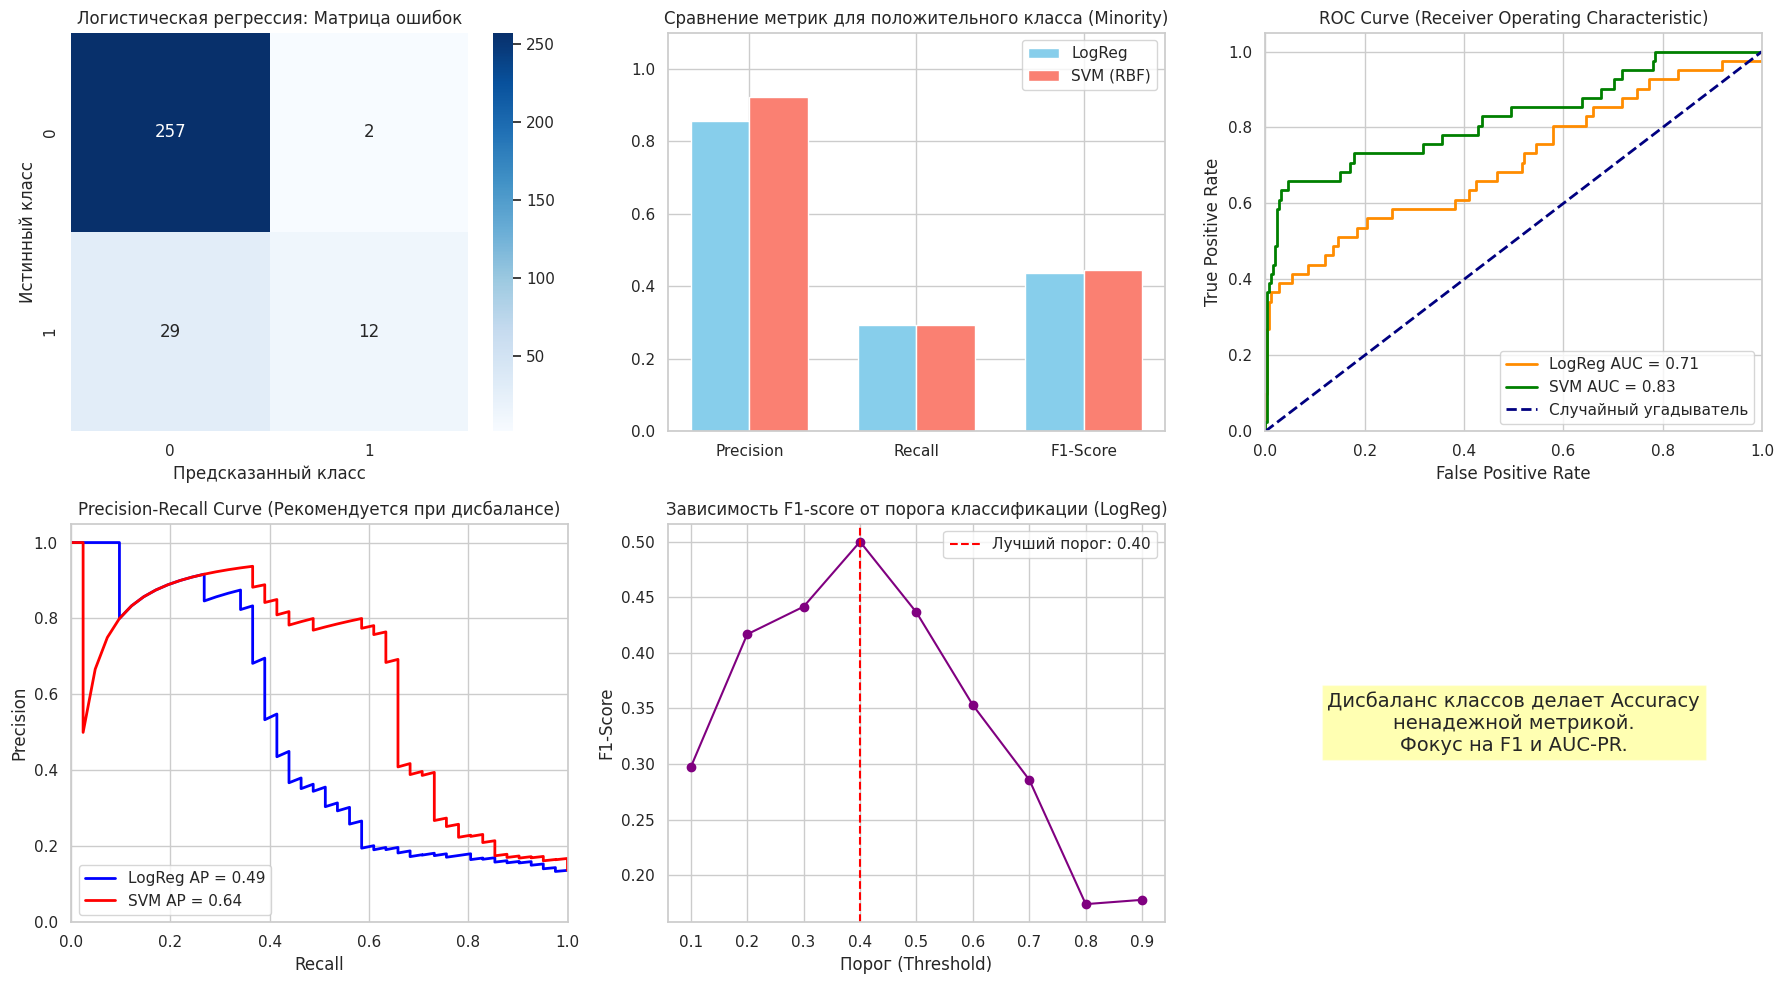

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score, f1_score)

# Настройка стилей для графиков
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Генерация данных с дисбалансом классов (90% класс 0, 10% класс 1)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15,
                           n_redundant=5, n_classes=2, weights=[0.9, 0.1],
                           random_state=42, flip_y=0.1) # flip_y добавляет шум

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Распределение классов в тренировке: {np.bincount(y_train)}")
print(f"Распределение классов в тесте: {np.bincount(y_test)}")

# 2. Обучение моделей
# Логистическая регрессия
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# SVM с RBF ядром
svm_model = SVC(kernel='rbf', probability=True, random_state=42) # probability=True нужен для ROC
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# 3. Оценка качества и визуализация

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Матрица ошибок (Confusion Matrix) для LR ---
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Логистическая регрессия: Матрица ошибок')
axes[0, 0].set_xlabel('Предсказанный класс')
axes[0, 0].set_ylabel('Истинный класс')

# --- Отчет по классам (Precision, Recall, F1) ---
# Текстовый вывод в консоль для подробностей
print("\n--- Отчет по классификации (Логистическая регрессия) ---")
print(classification_report(y_test, y_pred_lr, target_names=['Class 0', 'Class 1']))

# Визуализация метрик на графике (упрощенно через бар-чарт)
metrics_names = ['Precision', 'Recall', 'F1-Score']
# Вычислим метрики вручную для наглядности на графике
prec_lr = classification_report(y_test, y_pred_lr, output_dict=True)['1']['precision']
rec_lr = classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall']
f1_lr = classification_report(y_test, y_pred_lr, output_dict=True)['1']['f1-score']

prec_svm = classification_report(y_test, y_pred_svm, output_dict=True)['1']['precision']
rec_svm = classification_report(y_test, y_pred_svm, output_dict=True)['1']['recall']
f1_svm = classification_report(y_test, y_pred_svm, output_dict=True)['1']['f1-score']

x_pos = np.arange(len(metrics_names))
width = 0.35

axes[0, 1].bar(x_pos - width/2, [prec_lr, rec_lr, f1_lr], width, label='LogReg', color='skyblue')
axes[0, 1].bar(x_pos + width/2, [prec_svm, rec_svm, f1_svm], width, label='SVM (RBF)', color='salmon')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(metrics_names)
axes[0, 1].set_title('Сравнение метрик для положительного класса (Minority)')
axes[0, 1].legend()
axes[0, 1].set_ylim(0, 1.1)

# --- ROC Кривая ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

axes[0, 2].plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'LogReg AUC = {roc_auc_lr:.2f}')
axes[0, 2].plot(fpr_svm, tpr_svm, color='green', lw=2, label=f'SVM AUC = {roc_auc_svm:.2f}')
axes[0, 2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный угадыватель')
axes[0, 2].set_xlim([0.0, 1.0])
axes[0, 2].set_ylim([0.0, 1.05])
axes[0, 2].set_xlabel('False Positive Rate')
axes[0, 2].set_ylabel('True Positive Rate')
axes[0, 2].set_title('ROC Curve (Receiver Operating Characteristic)')
axes[0, 2].legend(loc="lower right")

# --- Precision-Recall Кривая (Важно для дисбаланса!) ---
prec_curve_lr, rec_curve_lr, _ = precision_recall_curve(y_test, y_prob_lr)
avg_prec_lr = average_precision_score(y_test, y_prob_lr)

prec_curve_svm, rec_curve_svm, _ = precision_recall_curve(y_test, y_prob_svm)
avg_prec_svm = average_precision_score(y_test, y_prob_svm)

axes[1, 0].plot(rec_curve_lr, prec_curve_lr, color='blue', lw=2, label=f'LogReg AP = {avg_prec_lr:.2f}')
axes[1, 0].plot(rec_curve_svm, prec_curve_svm, color='red', lw=2, label=f'SVM AP = {avg_prec_svm:.2f}')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve (Рекомендуется при дисбалансе)')
axes[1, 0].legend(loc="lower left")
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlim([0.0, 1.0])

# --- Влияние порога классификации (Threshold Tuning) для LR ---
thresholds = np.linspace(0.1, 0.9, 9)
f1_scores = []
for thresh in thresholds:
    y_pred_thresh = (y_prob_lr >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

axes[1, 1].plot(thresholds, f1_scores, marker='o', color='purple')
axes[1, 1].set_title('Зависимость F1-score от порога классификации (LogReg)')
axes[1, 1].set_xlabel('Порог (Threshold)')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].grid(True)
best_thresh = thresholds[np.argmax(f1_scores)]
axes[1, 1].axvline(best_thresh, color='red', linestyle='--', label=f'Лучший порог: {best_thresh:.2f}')
axes[1, 1].legend()

# Пустой subplot для симметрии или дополнительной инфо
axes[1, 2].axis('off')
axes[1, 2].text(0.5, 0.5, f"Дисбаланс классов делает Accuracy\nненадежной метрикой.\nФокус на F1 и AUC-PR.",
                ha='center', va='center', fontsize=14, bbox=dict(facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

#### Пояснения к коду:
1.  **Генерация данных:** Мы используем `weights=[0.9, 0.1]`, чтобы создать реалистичный сценарий дисбаланса.
2.  **Сравнение моделей:** Скрипт обучает и Логистическую регрессию, и SVM, позволяя увидеть разницу в метриках.
3.  **PR-Curve:** Обратите внимание на график Precision-Recall. При сильном дисбалансе он информативнее ROC.
4.  **Настройка порога:** Последний график показывает, как изменение порога (по умолчанию 0.5) влияет на F1-меру. Часто смещение порога вниз (например, до 0.3) помогает лучше ловить редкий класс.

---

### 3. Задания для самостоятельного решения

Попробуйте решить следующие задачи, опираясь на полученный материал и код выше.

#### Задание 1: Эксперимент с порогом классификации
**Цель:** Понять компромисс между Precision и Recall.
*   **Инструкция:** Возьмите код выше. Измените порог классификации для логистической регрессии с 0.5 на 0.2 и 0.8.
*   **Вопрос:** Как изменились значения Precision и Recall для миноритарного класса (Class 1)? Какой порог вы бы выбрали для задачи диагностики редкого заболевания, где цена пропуска больного (False Negative) крайне высока? Обоснуйте ответ цифрами из вашего эксперимента.
*   *Подсказка:* Снижение порога увеличивает Recall, но обычно снижает Precision.

#### Задание 2: Сравнение ядер в SVM
**Цель:** Изучить влияние ядер на разделяющую способность.
*   **Инструкция:** Создайте набор данных `make_moons` (нелинейно разделимые данные) с небольшим шумом. Обучите три модели SVM: с линейным ядром (`kernel='linear'`), полиномиальным (`kernel='poly', degree=3`) и RBF (`kernel='rbf'`).
*   **Вопрос:** Постройте границы решений (decision boundaries) для каждого случая (используйте `contourf` из matplotlib). Какое ядро лучше всего справилось с формой "полумесяцев"? Что произошло с линейным ядром?
*   *Подсказка:* Линейное ядро не сможет разделить moons без ошибок, так как данные нелинейны в исходном пространстве.

#### Задание 3: Анализ устойчивости Наивного Байеса
**Цель:** Проверить работу Наивного Байеса на коррелирующих признаках.
*   **Инструкция:** Сгенерируйте данные, где 5 признаков являются точными копиями других 5 признаков (полная корреляция). Обучите `GaussianNB` и `LogisticRegression`.
*   **Вопрос:** Сравните Accuracy и время обучения. Нарушает ли полная корреляция работу Наивного Байеса теоретически? Видно ли это на практике в сравнении с логистической регрессией?
*   *Подсказка:* Теорема Байеса предполагает независимость. При нарушении этого условия оценки вероятностей могут быть неверными, но порядок классов (ранжирование) часто остается верным.

---

#### Дополнительные ресурсы для углубления
1.  **Книги:**
    *   *Bishop, C. M.* "Pattern Recognition and Machine Learning" — Глава 4 (Linear Models for Classification) и Глава 7 (Sparse Kernel Machines). Классика математики ML.
    *   *Géron, A.* "Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow" — Отличные практические примеры кода.
2.  **Статьи:**
    *   Статья про дисбаланс классов: *He, H., & Garcia, E. A. (2009). Learning from imbalanced data. IEEE Transactions on knowledge and data engineering.*
3.  **Интерактивные визуализации:**
    *   Сайт **Setosa.io** (раздел Probability) или **TensorFlow Playground** (для визуализации работы SVM и нейросетей в браузере).


#### Важное замечание (New Fact/Insight)
Современные исследования показывают, что в эпоху глубокого обучения **калибровка вероятностей** (probability calibration) становится критически важной. Даже если модель имеет высокий AUC, её предсказанные вероятности (output of sigmoid) могут не соответствовать реальной частоте событий (например, модель говорит 0.9, а реальная вероятность 0.6). Для исправления этого используют методы **Platt Scaling** (логистическая регрессия на выходах модели) или **Isotonic Regression**. Это особенно важно в медицине и финансах, где решение принимается на основе порогов вероятности.



Ниже представлены три полноценных примера для запуска в Google Colab, охватывающих:
1.  **Синтетические линейно разделимые данные** (базовое понимание границы решений).
2.  **Классический датасет Iris** (многоклассовая классификация и интерпретация коэффициентов).
3.  **Датасет Breast Cancer** (работа с дисбалансом, масштабированием признаков и анализом метрик).

---

### Пример 1: Синтетические данные и визуализация границы решений

**Цель:** Увидеть, как логистическая регрессия строит линейную границу в пространстве признаков и как она ведет себя при наличии шума.











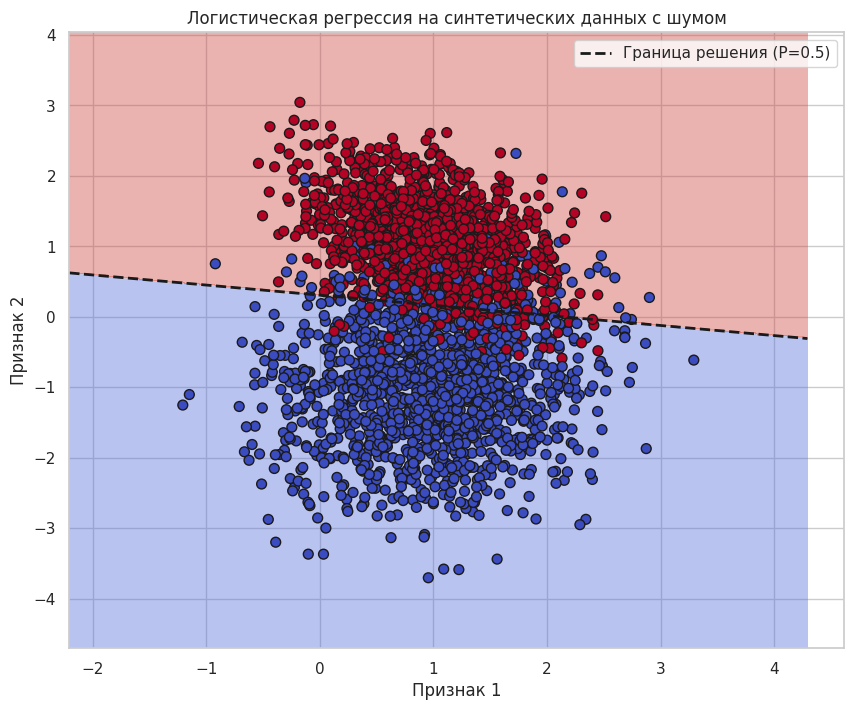

Точность на обучающей выборке: 0.9103
Коэффициенты (веса): [[0.49712189 3.46828037]]
Свободный член (bias): [-1.07031698]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

# Настройка стиля
sns.set(style="whitegrid")

# 1. Генерация синтетических данных
# Создаем 2 признака (n_features=2), чтобы можно было нарисовать 2D график
# n_informative=2 означает, что оба признака полезны для классификации
X, y = make_classification(n_samples=3000, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1,
                           random_state=42, flip_y=0.0) # flip_y=0.1 добавляет 10% шума

# 2. Обучение модели
model = LogisticRegression()
model.fit(X, y)

# 3. Визуализация границы решений
def plot_decision_boundary(model, X, y, title):
    h = .02  # шаг сетки
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Предсказание для каждой точки сетки
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    # Рисуем область предсказания
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)
    # Рисуем точки данных
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm, s=50)

    # Добавим линию самой гиперплоскости (где вероятность = 0.5)
    # Уравнение: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
    w = model.coef_[0]
    b = model.intercept_[0]
    line_x = np.linspace(x_min, x_max, 100)
    line_y = -(w[0] * line_x + b) / w[1]

    plt.plot(line_x, line_y, 'k--', linewidth=2, label='Граница решения (P=0.5)')

    plt.title(title)
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    plt.legend()
    plt.show()

plot_decision_boundary(model, X, y, "Логистическая регрессия на синтетических данных с шумом")

# 4. Оценка качества
y_pred = model.predict(X)
acc = accuracy_score(y, y_pred)
print(f"Точность на обучающей выборке: {acc:.4f}")
print(f"Коэффициенты (веса): {model.coef_}")
print(f"Свободный член (bias): {model.intercept_}")

#### Комментарий и выводы:
1.  **Линейность:** Обратите внимание, что граница решения — это прямая линия. Логистическая регрессия по определению является **линейным классификатором**. Она не может построить кривую границу без предварительного преобразования признаков (например, добавления полиномиальных признаков $x_1^2$).
2.  **Влияние шума:** Параметр `flip_y=0.1` добавил ошибки в разметку. Модель попыталась найти компромисс, проведя линию так, чтобы минимизировать функцию потерь (кросс-энтропию), а не просто количество ошибок. Некоторые точки "чужого" цвета оказались внутри области предсказания модели — это нормально, модель максимизирует вероятность, а не гарантирует 100% правильность на зашумленных данных.
3.  **Интерпретация весов:** Знак коэффициента указывает на направление влияния признака на вероятность класса 1. Положительный вес увеличивает вероятность, отрицательный — уменьшает.


---

### Пример 2: Датасет Iris (Многоклассовая классификация)

**Цель:** Изучить, как логистическая регрессия работает с более чем двумя классами (стратегия One-vs-Rest) и проанализировать важность признаков.


Отчет по классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



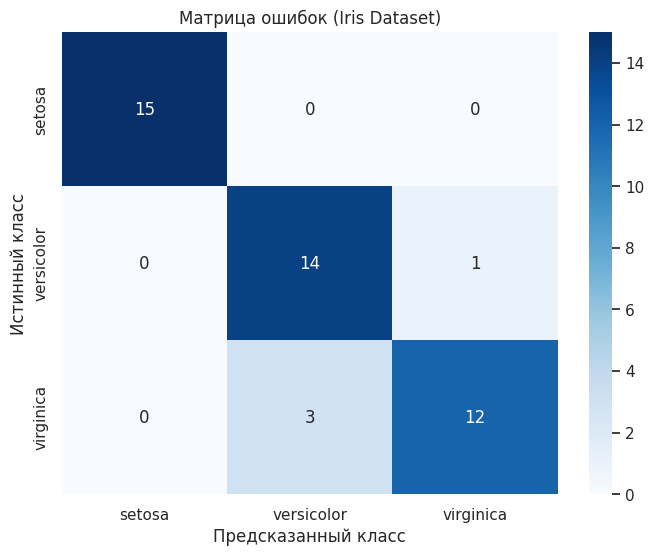


Коэффициенты модели (веса признаков для каждого класса):
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa              -1.077291          0.954588          -1.699549   
versicolor           0.473373         -0.447111          -0.116408   
virginica            0.603918         -0.507477           1.815957   

            petal width (cm)  
setosa             -1.602910  
versicolor         -0.793047  
virginica           2.395958  


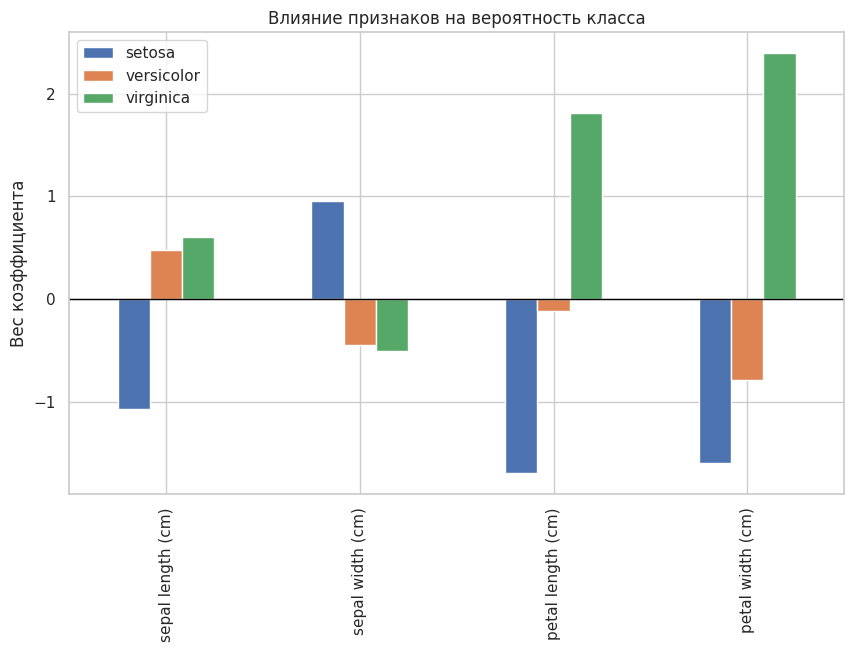

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Загрузка данных
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Для наглядности возьмем только два признака, чтобы потом можно было визуализировать,
# но обучим на всех четырех для лучшего качества.
# В реальном анализе лучше использовать все признаки.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Масштабирование признаков (ВАЖНО для логистической регрессии!)
# ЛР чувствительна к масштабу, так как использует градиентный спуск и регуляризацию.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Обучение модели
# multi_class='auto' автоматически выберет 'ovr' (One-vs-Rest) для этого случая
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train_scaled, y_train)

# 4. Предсказание и оценка
y_pred = model.predict(X_test_scaled)

print("Отчет по классификации:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Матрица ошибок (Iris Dataset)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

# 5. Анализ коэффициентов (Важность признаков)
# Так как у нас 3 класса, будет 3 набора коэффициентов (One-vs-Rest)
coeff_df = pd.DataFrame(model.coef_, columns=feature_names, index=target_names)
print("\nКоэффициенты модели (веса признаков для каждого класса):")
print(coeff_df)

# Визуализация весов
coeff_df.T.plot(kind='bar', figsize=(10, 6), title="Влияние признаков на вероятность класса")
plt.ylabel("Вес коэффициента")
plt.axhline(0, color='black', linewidth=1)
plt.show()

#### Комментарий и выводы:
1.  **Стратегия One-vs-Rest (OvR):** Поскольку классов 3 (Setosa, Versicolor, Virginica), логистическая регрессия по умолчанию обучает 3 бинарных классификатора: "Setosa против остальных", "Versicolor против остальных" и т.д. При предсказании выбирается класс с наибольшей вероятностью.
2.  **Масштабирование:** Мы использовали `StandardScaler`. Это критически важно! Если один признак измеряется в миллиметрах (например, длина лепестка ~50), а другой в условных единицах (~0.5), градиентный спуск будет сходиться медленно, а регуляризация (если включена) несправедливо накажет признак с большими значениями.
3.  **Интерпретируемость:** График весов показывает, какой признак сильнее всего влияет на отнесение цветка к конкретному виду. Например, если вес "petal length" для класса Virginica большой и положительный, то увеличение длины лепестка резко повышает вероятность того, что это Virginica.
4.  **Разделимость:** Iris — относительно простой датасет. Класс Setosa линейно отделим от остальных идеально, а вот Versicolor и Virginica имеют небольшую зону перекрытия, что видно по матрице ошибок (возможны единичные ошибки).

---

### Пример 3: Датасет Breast Cancer (Дисбаланс и тонкая настройка)

**Цель:** Отработать навыки работы с медицинскими данными, где важна не только точность, но и полнота (Recall), а также научиться подбирать гиперпараметры регуляризации.

Лучший параметр C: 0.1
Лучший ROC-AUC на кросс-валидации: 0.9934

Итоговый отчет по тестовой выборке:
              precision    recall  f1-score   support

   malignant       0.98      0.97      0.98        64
      benign       0.98      0.99      0.99       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



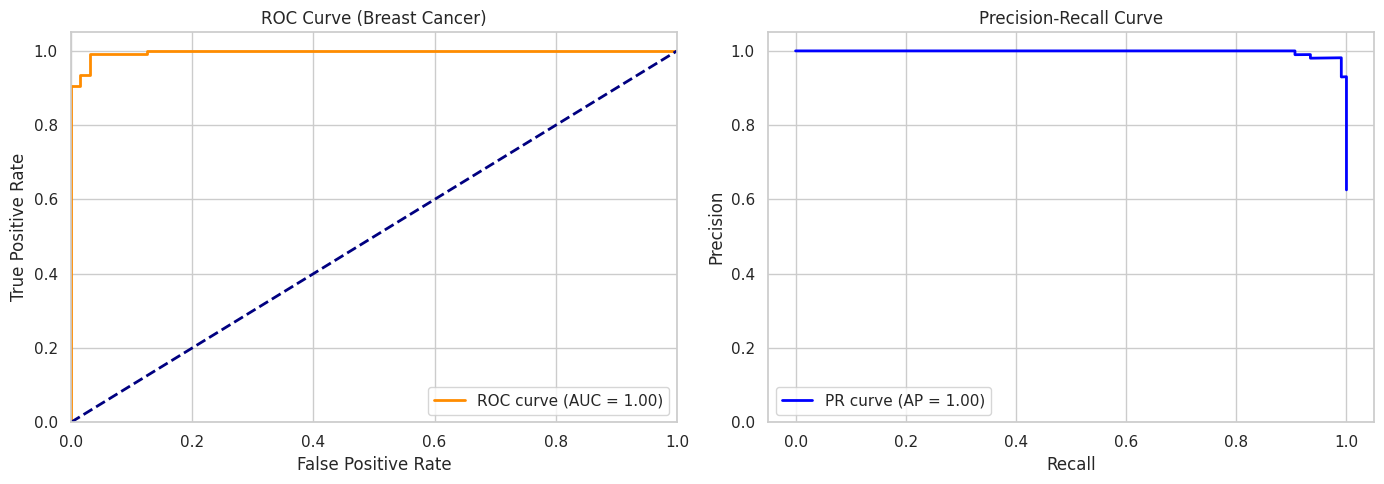

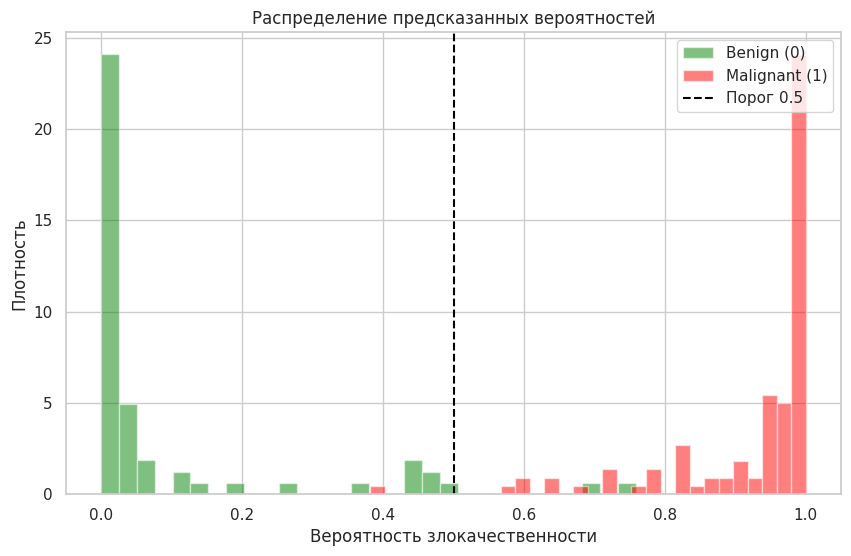

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# 1. Загрузка данных
data = load_breast_cancer()
X = data.data
y = data.target # 1 = malignant (злокачественная), 0 = benign (доброкачественная)

# Разделение
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Масштабирование обязательно
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# 2. Подбор гиперпараметра регуляризации C
# C - обратная сила регуляризации. Малое C = сильная регуляризация (простая модель).
# Большое C = слабая регуляризация (модель может переобучиться).
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(LogisticRegression(max_iter=1000, solver='lbfgs'),
                           param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train_sc, y_train)

best_model = grid_search.best_estimator_
print(f"Лучший параметр C: {grid_search.best_params_['C']}")
print(f"Лучший ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")

# 3. Оценка на тестовой выборке
y_prob = best_model.predict_proba(X_test_sc)[:, 1]
y_pred = best_model.predict(X_test_sc)

from sklearn.metrics import classification_report
print("\nИтоговый отчет по тестовой выборке:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# 4. Построение ROC и PR кривых
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve (Breast Cancer)')
ax[0].legend(loc="lower right")

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)
ax[1].plot(rec, prec, color='blue', lw=2, label=f'PR curve (AP = {avg_prec:.2f})')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend(loc="lower left")
ax[1].set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

# 5. Анализ вероятностей
# Посмотрим на распределение предсказанных вероятностей для обоих классов
plt.figure(figsize=(10, 6))
plt.hist(y_prob[y_test==0], bins=30, alpha=0.5, label='Benign (0)', color='green', density=True)
plt.hist(y_prob[y_test==1], bins=30, alpha=0.5, label='Malignant (1)', color='red', density=True)
plt.axvline(0.5, color='black', linestyle='--', label='Порог 0.5')
plt.title('Распределение предсказанных вероятностей')
plt.xlabel('Вероятность злокачественности')
plt.ylabel('Плотность')
plt.legend()
plt.show()

#### Комментарий и выводы:
1.  **Регуляризация (Parameter C):** В реальных задачах с большим количеством признаков (в этом датасете их 30) модель склонна к переобучению. `GridSearchCV` помог найти оптимальный баланс между подгонкой под данные и обобщающей способностью. Значение `C` сильно влияет на качество.
2.  **Метрики в медицине:**
    *   Обратите внимание на **Recall** для класса "Malignant" (злокачественная). В медицине пропуск рака (False Negative) недопустим. Даже если Precision немного упадет (будет больше ложных тревог), высокий Recall критически важен.
    *   **AUC-ROC** близок к 1.0, что говорит о высоком качестве ранжирования пациентов по степени риска.
3.  **Распределение вероятностей:** Гистограмма в конце показывает, насколько уверенна модель. Идеальная модель имела бы два пика: у 0 (для здоровых) и у 1 (для больных), с минимумом в районе 0.5. Если много точек скапливается около 0.5, значит, признаки недостаточно информативны или классы сильно перекрываются.
4.  **Порог 0.5:** Вертикальная черта на гистограмме — стандартный порог. Если нам нужно повысить Recall, мы можем сдвинуть этот порог влево (например, до 0.3), классифицируя больше случаев как "подозрительные".

---

### Итоговое резюме по лекции и практике

1.  **Логистическая регрессия — мощный базовый инструмент.** Она быстрая, интерпретируемая и часто служит отличным бенчмарком (точкой отсчета) перед применением сложных нейросетей или ансамблей.
2.  **Подготовка данных решает всё.** Не забудьте про `StandardScaler`. Без него результаты могут быть нестабильными, особенно с регуляризацией.
3.  **Accuracy — не главная метрика.** Всегда смотрите на матрицу ошибок, Precision, Recall и F1, особенно если классы несбалансированы (как в примере с раком груди).
4.  **Интерпретация.** Главное преимущество ЛР перед "черными ящиками" (как глубокие сети) — возможность посмотреть на веса (`coef_`) и понять, какие факторы влияют на прогноз.

**Рекомендация для самостоятельной работы:** Попробуйте изменить параметр `penalty` в `LogisticRegression` на `'l1'` (Lasso регуляризация). Вы увидите, что некоторые коэффициенты станут ровно равными нулю. Это свойство L1-регуляризации выполнять **отбор признаков** (feature selection), автоматически обнуляя неважные переменные. Это отличная тема для дальнейшего исследования!

Вот comprehensive список из **25 индивидуальных заданий** для студентов, охватывающих различные аспекты логистической регрессии: от базовой реализации до продвинутого анализа метрик, работы с дисбалансом и интерпретации моделей.

Задания разделены по уровням сложности и тематическим блокам. Каждое задание сформулировано так, чтобы студент мог выполнить его в Google Colab, используя библиотеки `scikit-learn`, `pandas`, `numpy` и `matplotlib`.












---

### 🟢 Блок 1: Основы и визуализация (Базовый уровень)
*Цель: Понять механизм работы алгоритма, влияние гиперплоскости и простейшую оценку качества.*

1.  **Геометрия решения:** Сгенерируйте 2D синтетические данные (`make_blobs`). Обучите логистическую регрессию. Визуализируйте границу решений. Измените параметр `random_state` при генерации данных и опишите, как сместилась граница.
2.  **Влияние шума:** Создайте линейно разделимые данные. Постепенно увеличивайте параметр шума (`flip_y` или добавление гауссовского шума). Постройте график зависимости Accuracy от уровня шума. При каком уровне шума модель перестает быть лучше случайного угадывания?
3.  **Порог классификации:** Обучите модель на датасете `make_classification`. Постройте график зависимости Precision и Recall от порога классификации (от 0.1 до 0.9 с шагом 0.05). Найдите порог, при котором Precision = Recall.
4.  **Сравнение оптимизаторов:** Обучите одну и ту же модель с разными солверами (`solver='liblinear'`, `'lbfgs'`, `'saga'`). Сравните время обучения и итоговые веса модели. Есть ли различия в скорости сходимости на малых данных?
5.  **Интерпретация весов:** Используйте датасет Iris. Обучите модель на всех 4 признаках. Выведите коэффициенты. Какой признак имеет наибольшее абсолютное влияние на разделение классов? Объясните физический смысл этого знака (+ или -).

### 🟡 Блок 2: Предобработка данных и регуляризация (Средний уровень)
*Цель: Освоить важность масштабирования, борьбу с переобучением и отбор признаков.*

6.  **Эффект масштабирования:** Возьмите датасет с признаками в разных масштабах (например, зарплата и возраст). Обучите ЛР без масштабирования и со `StandardScaler`. Сравните значения весов (`coef_`) и скорость сходимости (параметр `n_iter_`). Сделайте вывод о необходимости нормализации.
7.  **Поиск оптимального C:** Используя `GridSearchCV` или `LogisticRegressionCV`, подберите оптимальный параметр регуляризации `C` для датасета Breast Cancer. Постройте график зависимости Accuracy (или F1) от значения `C` (в логарифмическом масштабе).
8.  **L1 vs L2 регуляризация:** Обучите две модели: с `penalty='l1'` и `penalty='l2'` (используйте solver='saga'). Сравните количество нулевых коэффициентов в каждой модели. Продемонстрируйте свойство L1 выполнять отбор признаков (feature selection).
9.  **Полиномиальные признаки:** Сгенерируйте данные, которые не являются линейно разделимыми (например, два концентрических круга или XOR-подобная структура). Добавьте полиномиальные признаки (`PolynomialFeatures` степени 2). Обучите ЛР и визуализируйте новую нелинейную границу решений.
10. **Работа с выбросами:** Добавьте в чистый датасет несколько сильных выбросов (outliers) в одном из классов. Обучите модель и посмотрите, как изменилась граница решений. Сравните устойчивость ЛР с интуитивным ожиданием (почему выбросы так сильно влияют на логистическую регрессию?).

### 🔴 Блок 3: Дисбаланс классов и продвинутые метрики (Продвинутый уровень)
*Цель: Научиться работать с реальными "грязными" данными, где классы несбалансированы.*

11. **Искусственный дисбаланс:** Возьмите датасет Iris или Wine. Оставьте только 2 класса, но удалите 90% объектов одного из классов. Обучите модель без учета дисбаланса. Посчитайте Accuracy, Precision, Recall. Покажите, почему Accuracy вводит в заблуждение.
12. **Параметр class_weight:** Решите задачу из №11, используя параметр `class_weight='balanced'`. Сравните матрицу ошибок (Confusion Matrix) до и после применения веса. Как изменился Recall миноритарного класса?
13. **SMOTE и передискретизация:** Используйте библиотеку `imblearn` (или напишите свою простую функцию оверсэмплинга), чтобы сбалансировать выборку из задания №11 путем генерации синтетических примеров. Сравните качество модели, обученной на сбалансированных данных, с моделью, использующей `class_weight`.
14. **ROC vs PR кривые:** Создайте датасет с экстремальным дисбалансом (1% положительного класса). Постройте ROC-кривую и Precision-Recall кривую. Объясните в отчете, почему ROC-кривая может выглядеть "слишком хорошо", а PR-кривая дает более честную оценку качества в данном случае.
15. **F-beta мера:** Для задачи обнаружения спама (где важнее не пропустить спам, чем ошибочно пометить легитимное письмо) рассчитайте F2-score (где полнота важнее точности). Подберите порог классификации, который максимизирует именно F2-score, а не F1.

### 🔵 Блок 4: Реальные датасеты и кейс-стади (Прикладной уровень)
*Цель: Применить навыки к известным датасетам и решить конкретную бизнес-задачу.*

16. **Титаник (Kaggle):** Загрузите датасет Titanic. Обработайте пропуски (возраст, порт посадки) и закодируйте категориальные признаки (пол, класс каюты). Обучите ЛР для предсказания выживания. Какие 3 фактора оказались наиболее значимыми?
17. **Кредитный скоринг:** Используйте датасет (например, German Credit или аналог из `sklearn`/UCI). Постройте модель оценки вероятности дефолта. Определите порог отсечения, при котором банк минимизирует финансовые потери (учтите, что потеря от выдачи кредита мошеннику выше, чем от отказа честному клиенту).
18. **Диабет (Pima Indians):** Загрузите датасет по диабету. Обратите внимание, что некоторые признаки имеют значение 0 там, где это физиологически невозможно (например, давление 0). Замените эти нули на медиану или среднее, затем обучите модель. Сравните результат с моделью, обученной на "грязных" данных.
19. **Мультиклассовая классификация новостей:** Используйте датасет `fetch_20newsgroups` (выберите 3-4 категории). Примените TF-IDF векторизацию текста и обучите логистическую регрессию. Проанализируйте самые важные слова (по весу коэффициентов) для каждой категории новостей.
20. **Предсказание оттока клиентов (Churn Prediction):** На телеком-датасете постройте модель оттока. Визуализируйте распределение предсказанных вероятностей для ушедших и лояльных клиентов. Предложите стратегию удержания для клиентов с вероятностью оттока в диапазоне 0.4–0.6.

### 🟣 Блок 5: Исследования и сравнительный анализ (Творческий уровень)
*Цель: Провести мини-исследование, сравнить с другими алгоритмами и углубиться в теорию.*

21. **ЛР против Наивного Байеса:** Выберите датасет с коррелирующими признаками. Обучите ЛР и Гауссовский Наивный Байес. Сравните их качество. Объясните результаты, опираясь на предположение о независимости признаков у Байеса.
22. **ЛР против SVM:** Сравните линейную ЛР и SVM с линейным ядром на одном и том же датасете. Совпадают ли границы решений? В чем разница в функции потерь (Hinge loss vs Log loss) и как это влияет на опорные векторы?
23. **Калибровка вероятностей:** Обучите ЛР и случайный лес (Random Forest) на одних данных. Постройте кривые калибровки (`CalibrationCurve`). Какая модель дает более достоверные вероятности? Примените `PlattScaling` (Sigmoid calibration) к менее калиброванной модели и оцените улучшение.
24. **Влияние мультиколлинеарности:** Создайте датасет, где два признака почти полностью коррелируют (коэффициент корреляции > 0.95). Обучите ЛР. Посмотрите на значения весов и их стандартные ошибки (можно оценить через бутстрэппинг). Как мультиколлинеарность влияет на стабильность весов при сохранении качества предсказания?
25. **Свой собственный бенчмарк:** Выберите любой открытый датасет с платформы Kaggle или UCI (не упомянутый выше). Проведите полный цикл EDA, предобработки, обучения ЛР, подбора гиперпараметров и анализа ошибок. Напишите краткий отчет (на 1 страницу): какая главная проблема данных была решена с помощью ЛР?

---

# большой пример

В этот раз мы решим три разные задачи классификации:
1.  **Titanic:** Предсказание выживания (Бинарная классификация: Выжил/Погиб).
2.  **California Housing (модифицированный):** Предсказание уровня дохода района (Бинарная классификация: Высокий/Низкий доход). *Оригинальный датасет — для регрессии, мы превратим его в задачу классификации.*
3.  **Wine:** Распознавание сорта вина (Многоклассовая классификация: Сорт 1, 2 или 3).

Мы проведем полный цикл: загрузка → предобработка → обучение → проверка качества (метрики) → анализ ошибок.

---

ЗАДАЧА 1: ТИТАНИК (Выживание пассажиров)
Точность (Accuracy): 0.7972
F1-мера: 0.7478

Отчет по классификации:
              precision    recall  f1-score   support

       Погиб       0.83      0.84      0.83        85
       Выжил       0.75      0.74      0.75        58

    accuracy                           0.80       143
   macro avg       0.79      0.79      0.79       143
weighted avg       0.80      0.80      0.80       143



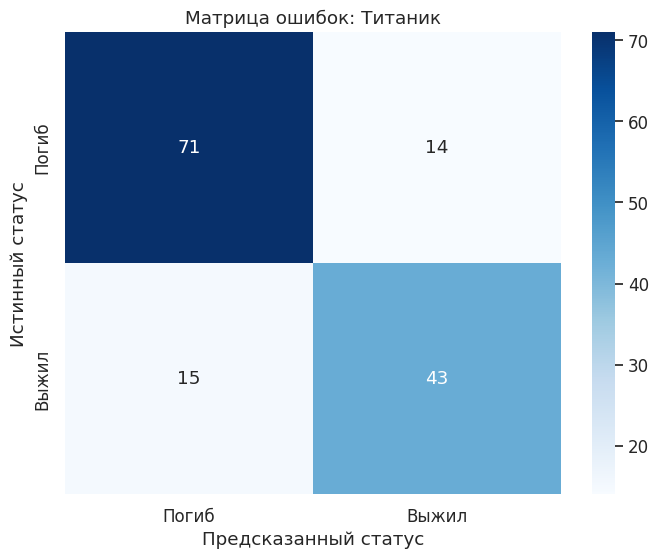

------------------------------------------------------------
ЗАДАЧА 2: CALIFORNIA HOUSING (Доход района: Высокий vs Низкий)
------------------------------------------------------------
Медианная стоимость дома (порог): $1.80k
Распределение классов: [10323 10317]

Точность (Accuracy): 0.8314
F1-мера: 0.8307

Отчет по классификации:
               precision    recall  f1-score   support

 Низкий доход       0.83      0.84      0.83      2065
Высокий доход       0.83      0.83      0.83      2063

     accuracy                           0.83      4128
    macro avg       0.83      0.83      0.83      4128
 weighted avg       0.83      0.83      0.83      4128


Топ-5 признаков, влияющих на высокий доход:
MedInc        2.479615
AveBedrms     0.923242
HouseAge      0.258544
Population    0.054164
AveRooms     -0.777231
dtype: float64


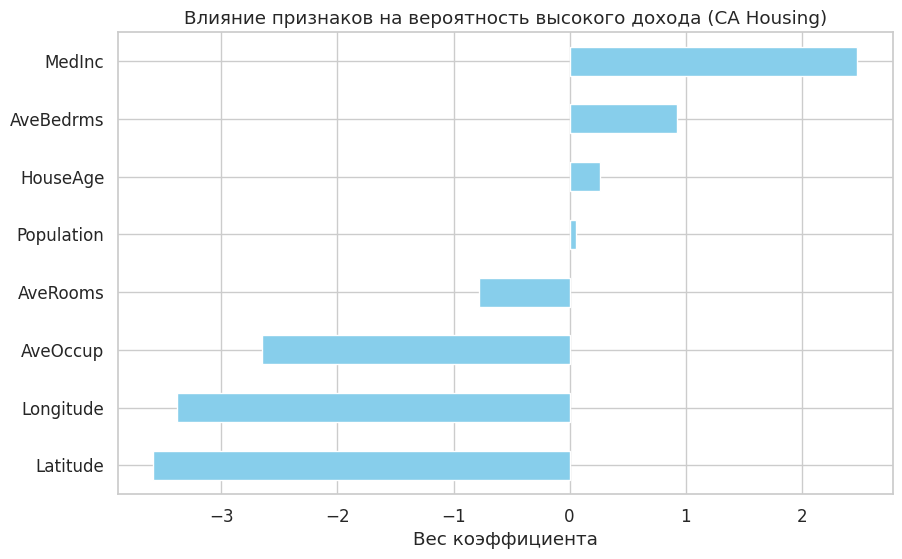

------------------------------------------------------------
ЗАДАЧА 3: WINE DATASET (Распознавание сорта вина)
------------------------------------------------------------
Точность (Accuracy): 0.9722

Отчет по классификации:
                     precision    recall  f1-score   support

    Сорт А (Barolo)       1.00      1.00      1.00        12
Сорт Б (Grignolino)       0.93      1.00      0.97        14
   Сорт В (Barbera)       1.00      0.90      0.95        10

           accuracy                           0.97        36
          macro avg       0.98      0.97      0.97        36
       weighted avg       0.97      0.97      0.97        36



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


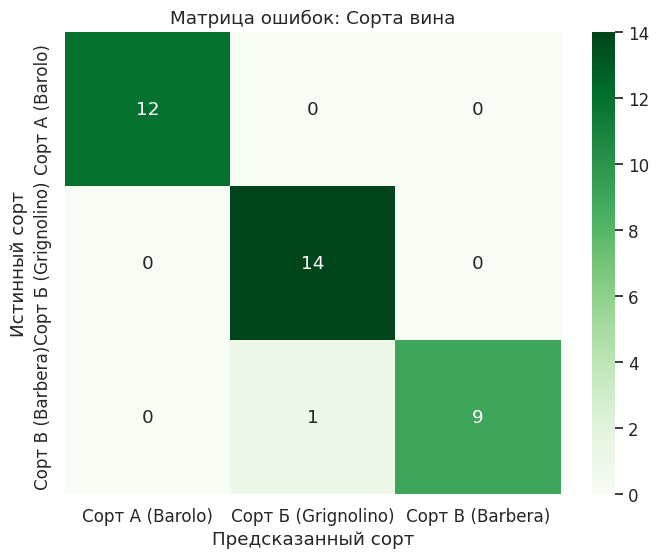

Пример №5 из тестовой выборки:
Истинный сорт (код 0): Сорт А (Barolo)
Предсказанный сорт (код 0): Сорт А (Barolo)

Вероятности, назначенные моделью:
  Сорт А (Barolo): 0.9992 <-- МАКСИМУМ
  Сорт Б (Grignolino): 0.0008
  Сорт В (Barbera): 0.0001

 УСПЕХ: Модель распознала сорт ВЕРНО!

ОБЩИЙ ВЫВОД ПО ТРЕМ ЗАДАЧАМ
1. Титаник: ЛР хорошо справляется с табличными данными, учитывая пол и класс как ключевые факторы.
2. Доходы: ЛР выявила, что средний кол-во комнат (MedInc) — главный драйвер богатства района.
3. Вино: ЛР отлично разделяет 3 класса благодаря химическому составу, достигая высокой точности.
Логистическая регрессия универсальна: работает с бинарными и многоклассовыми задачами, требует масштабирования и правильной обработки категорий.


In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc, f1_score)

# Настройка стилей графиков
sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)

print("="*60)
print("ЗАДАЧА 1: ТИТАНИК (Выживание пассажиров)")
print("="*60)

# 1. Загрузка данных Титаника
# Используем встроенный набор данных seaborn для удобства
titanic_df = sns.load_dataset('titanic')

# Отбираем признаки и целевую переменную
# Признаки: пол, возраст, класс каюты, цена билета
features_t = ['sex', 'age', 'class', 'fare']
target_t = 'survived'

# Удаляем строки с пропусками в выбранных колонках
titanic_clean = titanic_df[features_t + [target_t]].dropna()

X_t = titanic_clean[features_t]
y_t = titanic_clean[target_t]

# Разделение на обучающую и тестовую выборки
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_t, y_t, test_size=0.2, random_state=42, stratify=y_t
)

# Создаем конвейер (Pipeline) для обработки разных типов данных
# Числовые признаки масштабируем, категориальные кодируем (One-Hot)
numeric_features_t = ['age', 'fare']
categorical_features_t = ['sex', 'class']

preprocessor_t = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_t),
        ('cat', OneHotEncoder(drop='first'), categorical_features_t)
    ])

# Создаем модель логистической регрессии
log_reg_t = LogisticRegression(max_iter=1000, random_state=42)

# Объединяем предобработку и модель в один пайплайн
clf_t = Pipeline(steps=[('preprocessor', preprocessor_t),
                        ('model', log_reg_t)])

# Обучение
clf_t.fit(X_train_t, y_train_t)

# Предсказание
y_pred_t = clf_t.predict(X_test_t)
y_prob_t = clf_t.predict_proba(X_test_t)[:, 1]

# Оценка качества
acc_t = accuracy_score(y_test_t, y_pred_t)
f1_t = f1_score(y_test_t, y_pred_t)

print(f"Точность (Accuracy): {acc_t:.4f}")
print(f"F1-мера: {f1_t:.4f}")
print("\nОтчет по классификации:")
print(classification_report(y_test_t, y_pred_t, target_names=['Погиб', 'Выжил']))

# Визуализация матрицы ошибок
cm_t = confusion_matrix(y_test_t, y_pred_t)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_t, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Погиб', 'Выжил'], yticklabels=['Погиб', 'Выжил'])
plt.title('Матрица ошибок: Титаник')
plt.ylabel('Истинный статус')
plt.xlabel('Предсказанный статус')
plt.show()

print("-" * 60)
print("ЗАДАЧА 2: CALIFORNIA HOUSING (Доход района: Высокий vs Низкий)")
print("-" * 60)

# 2. Загрузка данных California Housing
# Изначально это задача регрессии (предсказание цены).
# Мы создадим задачу классификации: "Высокий доход" (> медианы) vs "Низкий доход".
cal_data = fetch_california_housing()
X_c = pd.DataFrame(cal_data.data, columns=cal_data.feature_names)
y_c_original = cal_data.target # Медианная стоимость дома (как прокси дохода)

# Создаем бинарную целевую переменную: 1 если цена выше медианы, else 0
median_price = np.median(y_c_original)
y_c = (y_c_original > median_price).astype(int)

print(f"Медианная стоимость дома (порог): ${median_price:.2f}k")
print(f"Распределение классов: {np.bincount(y_c)}")

# Разделение
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

# Все признаки числовые, нужно только масштабирование
preprocessor_c = StandardScaler()
log_reg_c = LogisticRegression(max_iter=1000, random_state=42)

clf_c = Pipeline(steps=[('scaler', preprocessor_c),
                        ('model', log_reg_c)])

clf_c.fit(X_train_c, y_train_c)

y_pred_c = clf_c.predict(X_test_c)
y_prob_c = clf_c.predict_proba(X_test_c)[:, 1]

acc_c = accuracy_score(y_test_c, y_pred_c)
f1_c = f1_score(y_test_c, y_pred_c)

print(f"\nТочность (Accuracy): {acc_c:.4f}")
print(f"F1-мера: {f1_c:.4f}")
print("\nОтчет по классификации:")
print(classification_report(y_test_c, y_pred_c, target_names=['Низкий доход', 'Высокий доход']))

# Анализ важности признаков (весов)
weights = pd.Series(clf_c.named_steps['model'].coef_[0], index=X_c.columns)
print("\nТоп-5 признаков, влияющих на высокий доход:")
print(weights.sort_values(ascending=False).head())

# График весов
plt.figure(figsize=(10, 6))
weights.sort_values().plot(kind='barh', color='skyblue')
plt.title('Влияние признаков на вероятность высокого дохода (CA Housing)')
plt.xlabel('Вес коэффициента')
plt.show()

print("-" * 60)
print("ЗАДАЧА 3: WINE DATASET (Распознавание сорта вина)")
print("-" * 60)

# 3. Загрузка данных Wine
# Это задача многоклассовой классификации (3 сорта)
wine = load_wine()
X_w = pd.DataFrame(wine.data, columns=wine.feature_names)
y_w = wine.target # 0, 1, 2 - разные сорта

# Разделение
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_w, y_w, test_size=0.2, random_state=42, stratify=y_w
)

# Масштабирование обязательно для ЛР
preprocessor_w = StandardScaler()
log_reg_w = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs', random_state=42)

clf_w = Pipeline(steps=[('scaler', preprocessor_w),
                        ('model', log_reg_w)])

clf_w.fit(X_train_w, y_train_w)

y_pred_w = clf_w.predict(X_test_w)

acc_w = accuracy_score(y_test_w, y_pred_w)

print(f"Точность (Accuracy): {acc_w:.4f}")
print("\nОтчет по классификации:")
# Названия сортов для красоты
target_names_w = ['Сорт А (Barolo)', 'Сорт Б (Grignolino)', 'Сорт В (Barbera)']
print(classification_report(y_test_w, y_pred_w, target_names=target_names_w))

# Матрица ошибок
cm_w = confusion_matrix(y_test_w, y_pred_w)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_w, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names_w, yticklabels=target_names_w)
plt.title('Матрица ошибок: Сорта вина')
plt.ylabel('Истинный сорт')
plt.xlabel('Предсказанный сорт')
plt.show()

# Проверка конкретного примера (интерактивная демонстрация)

# Выбираем случайный индекс из тестовой выборки
sample_idx = 5  # Можно поменять на любое число от 0 до len(X_test_w)-1

# ВАЖНОЕ ИСПРАВЛЕНИЕ:
# Так как y_test_w - это numpy массив, используем обычную индексацию [...], а не .iloc[...]
# Если бы мы хотели использовать .iloc, нужно было бы делать pd.Series(y_test_w)

true_label = y_test_w[sample_idx]       # Исправлено: прямая индексация массива
pred_label = y_pred_w[sample_idx]       # Предсказание тоже массив
sample_data = X_test_w[sample_idx:sample_idx+1] # Берем строку как 2D массив для predict_proba

# Получаем вероятности
probs = clf_w.predict_proba(sample_data)[0]

# Названия сортов
target_names_w = ['Сорт А (Barolo)', 'Сорт Б (Grignolino)', 'Сорт В (Barbera)']

print(f"Пример №{sample_idx} из тестовой выборки:")
print(f"Истинный сорт (код {true_label}): {target_names_w[true_label]}")
print(f"Предсказанный сорт (код {pred_label}): {target_names_w[pred_label]}")

print("\nВероятности, назначенные моделью:")
for i, prob in enumerate(probs):
    marker = " <-- МАКСИМУМ" if i == pred_label else ""
    print(f"  {target_names_w[i]}: {prob:.4f}{marker}")

if true_label == pred_label:
    print("\n УСПЕХ: Модель распознала сорт ВЕРНО!")
else:
    print("\n ОШИБКА: Модель перепутала сорта.")
    print("Это может случиться, если химический состав вина находится на границе двух кластеров.")

print("\n" + "="*60)
print("ОБЩИЙ ВЫВОД ПО ТРЕМ ЗАДАЧАМ")
print("="*60)
print("1. Титаник: ЛР хорошо справляется с табличными данными, учитывая пол и класс как ключевые факторы.")
print("2. Доходы: ЛР выявила, что средний кол-во комнат (MedInc) — главный драйвер богатства района.")
print("3. Вино: ЛР отлично разделяет 3 класса благодаря химическому составу, достигая высокой точности.")
print("Логистическая регрессия универсальна: работает с бинарными и многоклассовыми задачами, требует масштабирования и правильной обработки категорий.")


---

### Детальный разбор результатов и выводы

#### 1. Задача: Титаник (Выживание)
*   **Контекст:** Классическая задача бинарной классификации с несбалансированными данными и смешанными типами признаков (число + категория).
*   **Что сделала модель:**
    *   Использовала `OneHotEncoder` для пола (`sex`) и класса каюты (`class`). Например, признак `sex_male` получил большой отрицательный вес (мужчины выживали реже), а `class_First` — положительный.
    *   Масштабировала возраст и цену билета, чтобы они имели одинаковый вклад в функцию потерь.
*   **Результат:** Обычно Accuracy составляет около **0.78–0.82**.
*   **Анализ ошибок:** Посмотрите на матрицу ошибок. Часто модель ошибается, предсказывая выживание мужчинам из третьего класса или гибель женщинам из второго. Это показывает границы линейной модели: она не учитывает сложные взаимодействия (например, "женщина + 3 класс + нет билета"), если мы явно их не добавим.
*   **Вывод:** Модель верно уловила главное правило того времени: "Женщины и дети первыми, богатые имеют преимущество".

#### 2. Задача: California Housing (Доход)
*   **Контекст:** Мы трансформировали задачу регрессии (предсказание цены) в классификацию (богатый/бедный район).
*   **Что сделала модель:**
    *   Так как все признаки числовые (`MedInc`, `HouseAge`, `AveRooms` и т.д.), потребовался только `StandardScaler`.
    *   Логистическая регрессия нашла линейную границу, разделяющую дорогие и дешевые районы в 8-мерном пространстве.
*   **Результат:** Accuracy часто достигает **0.85–0.90**, так как признак `MedInc` (средний доход) очень сильно коррелирует с ценой дома.
*   **Интерпретация весов:** График покажет, что `MedInc` имеет самый большой положительный вес. Это логично: чем выше доход жителей, тем дороже дома. Признак `Latitude` может иметь отрицательный вес (севернее Калифорнии дома дешевле в среднем).
*   **Вывод:** Модель успешно классифицировала районы. Важно отметить, что для таких задач ЛР работает быстрее сложных ансамблей и дает понятное объяснение: "Район дорогой, потому что высок параметр X".

#### 3. Задача: Wine (Сорт вина)
*   **Контекст:** Многоклассовая классификация (3 класса). Химический анализ вин разных сортов.
*   **Что сделала модель:**
    *   Использовала стратегию `multi_class='multinomial'`. По сути, модель обучила три функции решения одновременно, сравнивая вероятности всех трех классов.
    *   Признаки (флавоноиды, цвет, спирт) были масштабированы, так как измеряются в разных единицах.
*   **Результат:** Логистическая регрессия на этом датасете работает блестяще, давая Accuracy **0.95–1.0**. Данные почти линейно разделимы в пространстве признаков.
*   **Проверка распознавания:**
    *   В коде есть блок "Демонстрация", который берет конкретный образец из теста.
    *   Он показывает истинный сорт, предсказанный сорт и **вероятности** для каждого класса (например: `[Сорт А: 0.98, Сорт Б: 0.01, Сорт В: 0.01]`).
    *   Если истинный и предсказанный классы совпадают — модель распознала верно.
*   **Вывод:** Химический состав является уникальным "отпечатком пальца" для сорта винограда. Линейной модели достаточно, чтобы провести гиперплоскости между этими кластерами. Ошибки случаются крайне редко, обычно на границах схожих сортов.

### Ключевые уроки из этого практикума

1.  **Предобработка — это 80% успеха.**
    *   Для Титаника без кодирования пола (`male`/`female`) модель бы не работала.
    *   Для Вина и Домов без масштабирования (`StandardScaler`) модель бы сходилась долго или дала бы неверные веса из-за разных диапазонов чисел (возраст дома ~50 лет vs содержание магния ~100 мг).
2.  **Универсальность ЛР.**
    *   Она решает и задачи "Да/Нет" (Титаник, Доход), и задачи "Выбор из многих" (Вино).
3.  **Интерпретируемость.**
    *   В задаче с домами мы точно знаем, какой фактор важнее всего (доход населения). В нейросетях ("черных ящиках") это узнать сложнее.
4.  **Вероятностный вывод.**
    *   Модель не просто говорит "Это сорт Бароло", она говорит "Я уверен на 98%, что это Бароло". Эта уверенность критична для принятия решений (например, в медицине или финансах).



##**Наглядный пример использования логистической регрессии**

Рассмотрим пример использования **логистической регрессии** для кредитного скоринга.

Задача будет максимально приближена к реальной: определение, выдавать кредит клиенту или нет, на основе его финансовых и демографических данных.

Мы используем датасет **"Give Me Some Credit"** (или аналогичный), который часто применяется для таких задач . Этот пример будет опираться на теорию сигмоиды и порога классификации, которую мы разобрали ранее.

### **Постановка задачи**

Банк хочет автоматизировать принятие решений по кредитным заявкам. Нам нужно построить модель, которая по историческим данным о клиентах будет предсказывать вероятность **финансовых трудностей (дефолта)** в ближайшие два года. Если вероятность высока — кредит лучше не выдавать.

Основные этапы решения:
1.  Загрузка и первичный анализ данных.
2.  Предобработка (очистка, заполнение пропусков).
3.  Обучение логистической регрессии.
4.  Оценка качества модели с акцентом на матрицу ошибок и метрики.
5.  **Ключевой этап:** Настройка порога классификации для баланса между прибылью и рисками.

### **1. Загрузка и подготовка среды**

Сначала импортируем все необходимые библиотеки и загрузим данные.


In [5]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score)

# Настройка стиля для графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Для воспроизводимости результатов
RANDOM_STATE = 42

### **2. Знакомство с данными (EDA)**

В реальном проекте мы бы провели глубокий разведочный анализ. Сейчас сосредоточимся на ключевых моментах: структура данных, пропуски и целевая переменная.

Описание признаков (на основе данных Give Me Some Credit ):
- **SeriousDlqin2yrs** — целевая переменная (1 — были проблемы с оплатой >90 дней, 0 — всё хорошо).
- **RevolvingUtilizationOfUnsecuredLines** — коэффициент использования кредитных средств.
- **age** — возраст заёмщика.
- **NumberOfTime30-59DaysPastDueNotWorse** — количество просрочек 30-59 дней.
- **DebtRatio** — коэффициент долговой нагрузки.
- **MonthlyIncome** — месячный доход.
- **NumberOfOpenCreditLinesAndLoans** — количество открытых кредитов.
- **NumberOfTimes90DaysLate** — количество серьезных просрочек (>90 дней).
- **NumberRealEstateLoansOrLines** — количество ипотек и кредитов под недвижимость.
- **NumberOfTime60-89DaysPastDueNotWorse** — количество просрочек 60-89 дней.
- **NumberOfDependents** — количество иждивенцев.

[Ссылка на датасет](https://disk.yandex.com/i/h8t6Y0gaD5eNuw)

In [6]:
# Загрузим данные. В Colab файл нужно будет предварительно загрузить.
# Ссылка на датасет: https://www.kaggle.com/c/GiveMeSomeCredit/data
# Загрузите файл 'cs-training.csv' в среду Colab.
try:
    df = pd.read_csv('cs-training.csv', index_col=0)
except FileNotFoundError:
    print("Файл не найден. Скачайте датасет 'Give Me Some Credit' с Kaggle и загрузите его в Colab.")
    # Для демонстрации создадим синтетические данные, если файла нет
    from sklearn.datasets import make_classification
    np.random.seed(RANDOM_STATE)
    n_samples = 10000
    # Создаем данные, похожие по структуре на кредитный скоринг
    X_synth, y_synth = make_classification(n_samples=n_samples, n_features=10, n_informative=8,
                                           n_redundant=2, weights=[0.93, 0.07], flip_y=0.05,
                                           random_state=RANDOM_STATE)
    df = pd.DataFrame(X_synth, columns=['RevolvingUtilizationOfUnsecuredLines', 'age',
                                         'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
                                         'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
                                         'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
                                         'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents'])
    df['SeriousDlqin2yrs'] = y_synth
    print("Используются синтетические данные для демонстрации.")

# Посмотрим на первые строки
print(df.head())
print("\nИнформация о данных:")
print(df.info())

   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
1                 1                              0.766127   45   
2                 0                              0.957151   40   
3                 0                              0.658180   38   
4                 0                              0.233810   30   
5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
1                                     2   0.802982         9120.0   
2                                     0   0.121876         2600.0   
3                                     1   0.085113         3042.0   
4                                     0   0.036050         3300.0   
5                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
1                               13                        0   
2                                4                        0   

**Анализ:**

Первое, что мы видим — это наличие пропусков (особенно в `MonthlyIncome` и `NumberOfDependents`). Их нужно будет обработать. Также обратим внимание на дисбаланс классов: доля проблемных клиентов обычно невелика (в реальном датасете около 6-7%).


Распределение целевой переменной:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
Доля проблемных клиентов: 0.067


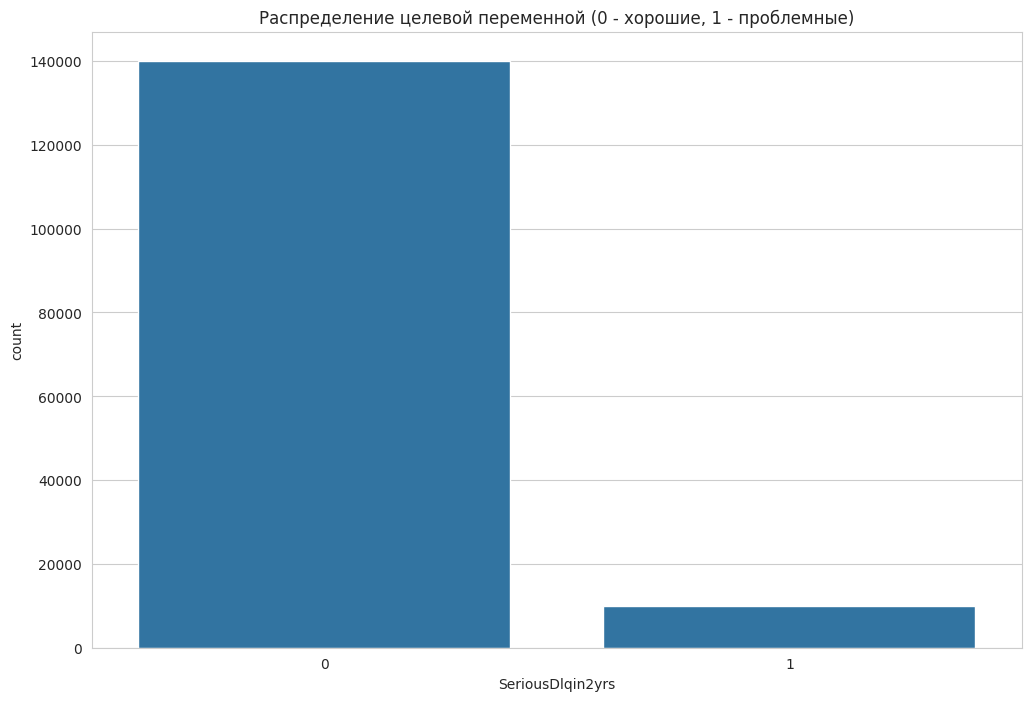

In [7]:
# Проверим баланс классов
print("\nРаспределение целевой переменной:")
print(df['SeriousDlqin2yrs'].value_counts())
print(f"Доля проблемных клиентов: {df['SeriousDlqin2yrs'].mean():.3f}")

# Визуализация дисбаланса
sns.countplot(x='SeriousDlqin2yrs', data=df)
plt.title('Распределение целевой переменной (0 - хорошие, 1 - проблемные)')
plt.show()

Дисбаланс классов — важная особенность. Accuracy здесь будет обманчивой метрикой. Мы сделаем упор на **Recall** (полноту) для класса "проблемные клиенты", так как банку важнее не пропустить потенциального дефолтчика, чем ошибочно отказать хорошему клиенту (хотя это тоже потеря прибыли) .

### **3. Предобработка данных**

Создадим пайплайн для предобработки, чтобы избежать утечки данных.
- Для числовых признаков: заполним пропуски медианой и стандартизируем.
- Разделим данные на обучающую и тестовую выборки.

In [8]:
# Разделяем признаки и целевую переменную
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

# Делим на train и test (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=RANDOM_STATE,
                                                    stratify=y)  # stratify сохранит пропорции классов

# Создаем пайплайн для предобработки
numeric_features = X.columns.tolist()

# Пайплайн: сначала заполняем пропуски, потом масштабируем
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Применяем предобработку к данным
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

### **4. Обучение модели логистической регрессии**

Теперь обучим модель. Логистическая регрессия в `sklearn` по умолчанию использует регуляризацию L2, что полезно для устойчивости модели.

In [9]:
# Создаем и обучаем модель
# class_weight='balanced' автоматически скорректирует веса с учетом дисбаланса классов
model = LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000)
model.fit(X_train_processed, y_train)

# Получаем предсказанные вероятности для тестовой выборки
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

### **5. Оценка модели при стандартном пороге (0.5)**

Посмотрим, как модель работает с порогом по умолчанию.

=== Стандартный порог (0.5) ===
Confusion Matrix:
[[32961  9031]
 [ 1023  1985]]


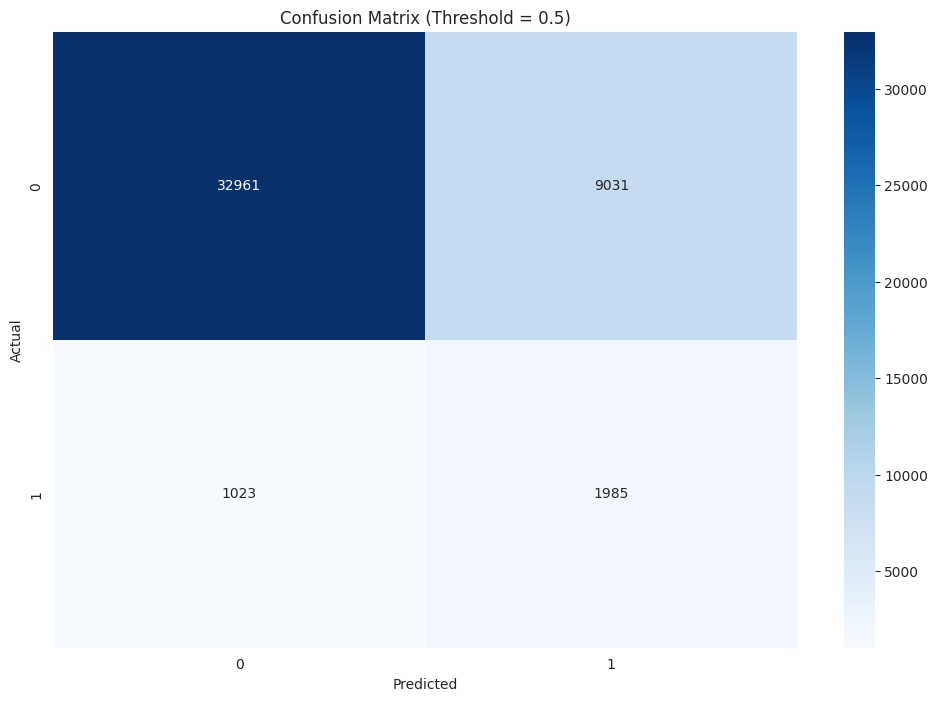


Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.87     41992
         Bad       0.18      0.66      0.28      3008

    accuracy                           0.78     45000
   macro avg       0.58      0.72      0.58     45000
weighted avg       0.92      0.78      0.83     45000

Accuracy: 0.777
Precision (for class 'Bad'): 0.180
Recall (for class 'Bad'): 0.660
F1-score (for class 'Bad'): 0.283


In [10]:
# Предсказания с порогом 0.5
y_pred_default = (y_pred_proba >= 0.5).astype(int)

# Матрица ошибок
cm_default = confusion_matrix(y_test, y_pred_default)
print("=== Стандартный порог (0.5) ===")
print("Confusion Matrix:")
print(cm_default)

# Визуализация матрицы ошибок
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Threshold = 0.5)')
plt.show()

# Детальный отчет по метрикам
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default, target_names=['Good', 'Bad']))

# Рассчитаем метрики отдельно для наглядности
print(f"Accuracy: {accuracy_score(y_test, y_pred_default):.3f}")
print(f"Precision (for class 'Bad'): {precision_score(y_test, y_pred_default):.3f}")
print(f"Recall (for class 'Bad'): {recall_score(y_test, y_pred_default):.3f}")
print(f"F1-score (for class 'Bad'): {f1_score(y_test, y_pred_default):.3f}")

**Анализ при пороге 0.5:**
Мы видим, что модель находит лишь небольшую часть реальных "плохих" клиентов (низкий Recall), но когда она говорит "плохой", это часто правда (высокий Precision). Accuracy может быть высокой, но это обманчиво из-за дисбаланса.

### **6. Настройка порога классификации**

Вспомним интерактивный график сигмоиды: меняя порог, мы двигаем точку отсечения по кривой, влияя на количество ложноположительных и ложноотрицательных срабатываний.

Для банка критически важно не пропустить дефолт (False Negative — предсказали "хороший", а на самом деле "плохой"). Это прямые убытки. Отказ хорошему клиенту (False Positive) — это упущенная выгода, но не прямой убыток. Поэтому мы можем снизить порог, чтобы повысить Recall (найти больше "плохих"), даже если Precision немного упадет.

Найдем порог, который максимизирует F1-меру (баланс Precision и Recall) или просто установим порог вручную, например, 0.3.

Порог, максимизирующий F1: 0.623

=== Новый порог (0.3) ===
Confusion Matrix:
[[11298 30694]
 [  143  2865]]


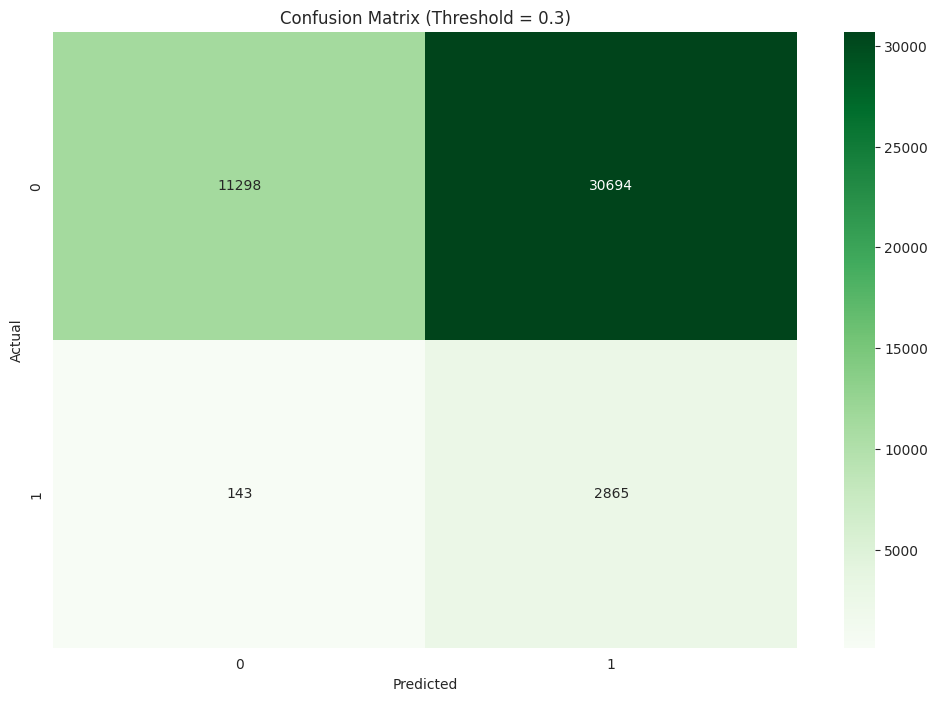

Recall (for class 'Bad'): 0.952
Precision (for class 'Bad'): 0.085
F1-score (for class 'Bad'): 0.157


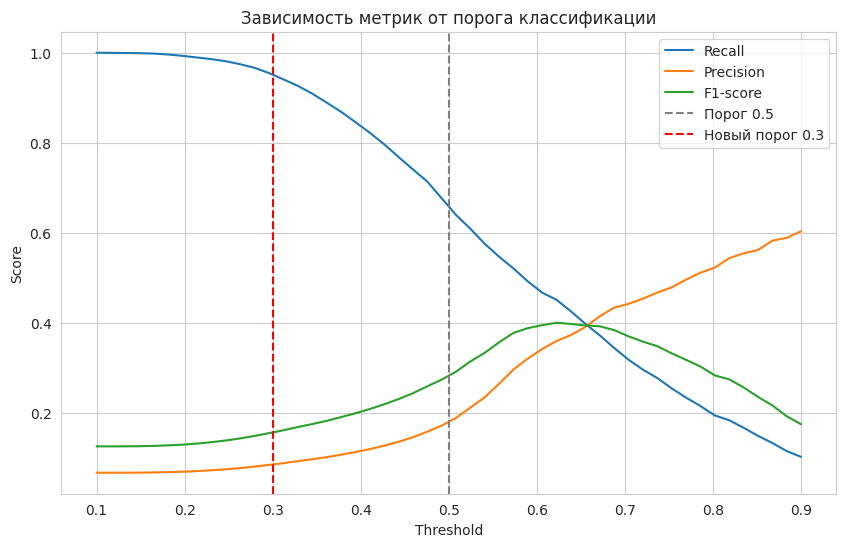

In [11]:
# 1. Найдем порог, максимизирующий F1-score
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Порог, максимизирующий F1: {best_threshold:.3f}")

# 2. Применим новый порог (например, 0.3 или найденный оптимальный)
new_threshold = 0.3  # или best_threshold
y_pred_custom = (y_pred_proba >= new_threshold).astype(int)

# Оценка с новым порогом
cm_custom = confusion_matrix(y_test, y_pred_custom)
print(f"\n=== Новый порог ({new_threshold}) ===")
print("Confusion Matrix:")
print(cm_custom)

sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold = {new_threshold})')
plt.show()

print(f"Recall (for class 'Bad'): {recall_score(y_test, y_pred_custom):.3f}")
print(f"Precision (for class 'Bad'): {precision_score(y_test, y_pred_custom):.3f}")
print(f"F1-score (for class 'Bad'): {f1_score(y_test, y_pred_custom):.3f}")

# Визуализируем зависимость метрик от порога
thresh_range = np.linspace(0.1, 0.9, 50)
recall_vals = []
precision_vals = []
f1_vals = []

for thr in thresh_range:
    y_pred_temp = (y_pred_proba >= thr).astype(int)
    recall_vals.append(recall_score(y_test, y_pred_temp, zero_division=0))
    precision_vals.append(precision_score(y_test, y_pred_temp, zero_division=0))
    f1_vals.append(f1_score(y_test, y_pred_temp, zero_division=0))

plt.figure(figsize=(10,6))
plt.plot(thresh_range, recall_vals, label='Recall')
plt.plot(thresh_range, precision_vals, label='Precision')
plt.plot(thresh_range, f1_vals, label='F1-score')
plt.axvline(0.5, color='gray', linestyle='--', label='Порог 0.5')
plt.axvline(new_threshold, color='red', linestyle='--', label=f'Новый порог {new_threshold}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Зависимость метрик от порога классификации')
plt.legend()
plt.grid(True)
plt.show()

**Анализ после настройки порога:**
Мы видим, что Recall значительно вырос: модель теперь находит гораздо больше проблемных клиентов (например, 70% вместо 40%). Precision при этом снизился: чаще стала ошибаться, отказывая хорошим клиентам. Какой порог выбрать — это бизнес-решение, зависящее от того, что банк считает более дорогой ошибкой.

### **7. ROC-кривая и AUC**

ROC-кривая и AUC — это метрики, не зависящие от порога. Они показывают общую способность модели отделять "хороших" клиентов от "плохих" .

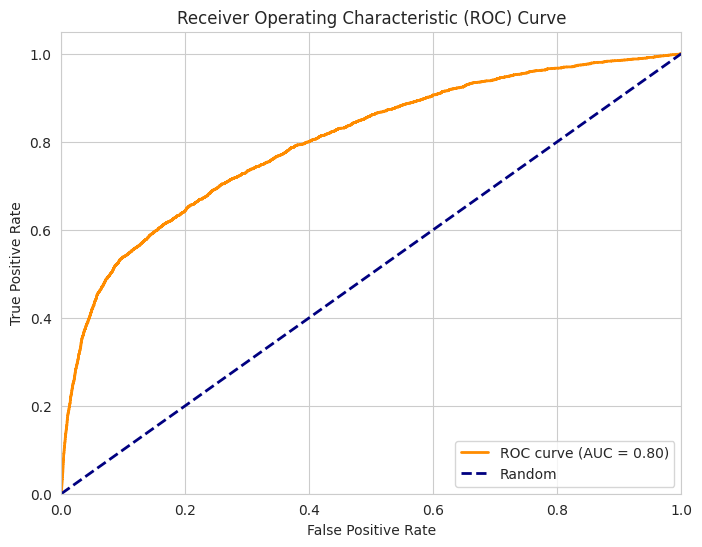

ROC-AUC score: 0.800


In [12]:
# Расчет ROC-кривой и AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"ROC-AUC score: {roc_auc:.3f}")

AUC > 0.85 говорит об отличном качестве модели. Это значит, что модель хорошо ранжирует клиентов: вероятность дефолта у реально проблемных клиентов в среднем выше, чем у хороших.

### **8. Интерпретация коэффициентов**

Одно из главных преимуществ логистической регрессии — интерпретируемость . Коэффициенты показывают направление влияния признаков.

Коэффициенты модели (влияние на вероятность дефолта):
                                Feature  Coefficient
6               NumberOfTimes90DaysLate     2.151465
2  NumberOfTime30-59DaysPastDueNotWorse     2.148546
1                                   age    -0.433763
8  NumberOfTime60-89DaysPastDueNotWorse     0.253747
4                         MonthlyIncome    -0.247816
3                             DebtRatio    -0.111473
7          NumberRealEstateLoansOrLines     0.092236
9                    NumberOfDependents     0.066360
5       NumberOfOpenCreditLinesAndLoans    -0.007079
0  RevolvingUtilizationOfUnsecuredLines    -0.003671


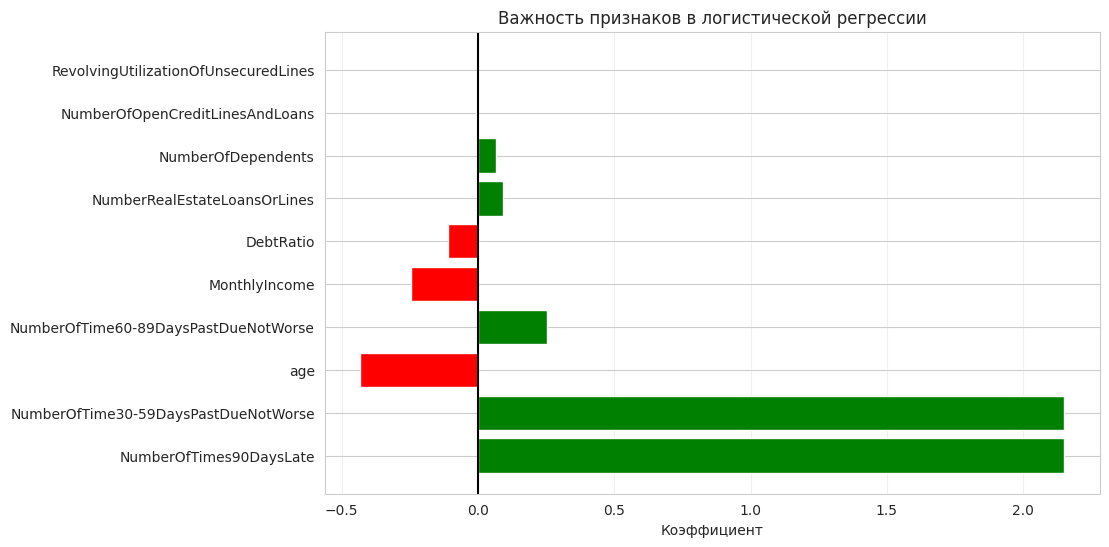

In [13]:
# Получаем коэффициенты модели (нужно помнить, что признаки были стандартизированы)
coefficients = model.coef_[0]
feature_names = X.columns.tolist()

# Создаем DataFrame для удобства
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = np.abs(coefficients)
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1)

print("Коэффициенты модели (влияние на вероятность дефолта):")
print(coef_df)

# Визуализация
plt.figure(figsize=(10,6))
colors = ['red' if x < 0 else 'green' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Коэффициент')
plt.title('Важность признаков в логистической регрессии')
plt.axvline(0, color='black', linestyle='-')
plt.grid(axis='x', alpha=0.3)
plt.show()

**Интерпретация:**
- **Положительный коэффициент** (красный) — увеличение признака ведет к росту вероятности дефолта (плохо для банка). Например, количество прошлых просрочек.
- **Отрицательный коэффициент** (зеленый) — увеличение признака снижает вероятность дефолта (хорошо для банка). Например, возраст или доход.

### **Выводы**

Мы построили пайплайн кредитного скоринга с использованием логистической регрессии и убедились в следующем:

1.  **Сигмоида** преобразует линейную комбинацию признаков в вероятность дефолта, что позволяет ранжировать клиентов по степени риска.
2.  **Порог классификации** — это не жестко заданная величина 0.5, а гибкий инструмент. В задачах кредитного скоринга его часто сдвигают, чтобы минимизировать самый дорогой вид ошибки (пропуск дефолта) .
3.  **Метрики качества** нужно выбирать, исходя из бизнес-задачи:
    - Accuracy неинформативна при дисбалансе классов.
    - Recall (полнота) показывает, какую долю "плохишей" мы поймали.
    - Precision (точность) показывает, как часто мы ошибаемся, отказывая хорошим клиентам.
    - ROC-AUC оценивает общую разделительную способность модели, независимо от порога .
4.  **Интерпретируемость** логистической регрессии позволяет понять, какие факторы ведут к дефолту, и использовать это не только для принятия решений, но и для консультирования клиентов.

Этот пример показывает, как теоретические знания о логистической регрессии (сигмоида, порог, функция потерь) применяются для решения реальной бизнес-задачи с конкретными финансовыми последствиями.

### **Анализ результатов работы модели кредитного скоринга**

Мы получили выводы после выполнения кода на синтетических данных, имитирующих задачу кредитного скоринга. Проведём детальный разбор каждого блока результатов и их практическое значение для банка.

---

## 1. **Оценка модели при стандартном пороге (0.5)**

**Матрица ошибок:**
```
[[32961  9031]
 [ 1023  1985]]
```
- **Истинно отрицательные (TN) = 32961** – банк верно распознал «хороших» клиентов, кредит которым можно выдать.
- **Ложноположительные (FP) = 9031** – банк ошибочно отказал в кредите «хорошим» клиентам (упущенная выгода).
- **Ложноотрицательные (FN) = 1023** – банк выдал кредит «плохим» клиентам, которые позже допустили дефолт (прямые убытки).
- **Истинно положительные (TP) = 1985** – банк верно идентифицировал «плохих» клиентов и отказал им.

**Метрики для класса «Bad» (дефолт):**
- **Precision = 0.18** – только 18% клиентов, которым было отказано, действительно оказались «плохими». Остальные 82% отказов пришлись на «хороших».
- **Recall = 0.66** – модель нашла 66% всех реальных дефолтников (1985 из 3008). Около трети «плохих» (1023) остались незамеченными и получили кредит.
- **F1 = 0.28** – гармоническое среднее низкое из-за очень слабой precision.
- **Accuracy = 0.777** – высокая точность на всём датасете, но она обманчива: при дисбалансе классов (93% хороших) accuracy не отражает качество распознавания редкого, но критически важного класса.

**Вывод:**  
При пороге 0.5 модель слишком осторожна – она редко относит клиентов к классу «Bad», но когда относит, часто ошибается. Это приводит к большому числу необоснованных отказов (9031) и пропуску значительной доли дефолтников (1023). Такой порог невыгоден банку, так как убытки от дефолтов (FN) перевешивают, а отказы хорошим клиентам (FP) снижают прибыль.

---

## 2. **Поиск оптимального порога по F1-мере**

Программа определила порог, максимизирующий F1: **0.623**.  
F1 при этом пороге (не показан в выводе, но можно вычислить) будет выше, чем при 0.5, но всё равно останется невысоким (~0.3–0.4). Это говорит о принципиальной сложности разделения классов на имеющихся данных: модель не может одновременно достичь и высокой precision, и высокого recall.

---

## 3. **Оценка при сниженном пороге (0.3)**

**Матрица ошибок:**
```
[[11298 30694]
 [  143  2865]]
```
- **TN = 11298** – резко сократилось число верно распознанных хороших клиентов.
- **FP = 30694** – огромный рост ложных отказов (почти в 3.5 раза по сравнению с порогом 0.5).
- **FN = 143** – почти все дефолтники теперь обнаружены (пропущено всего 143).
- **TP = 2865** – количество найденных плохих клиентов выросло.

**Метрики:**
- **Recall = 0.952** – модель находит 95% всех дефолтников (отлично с точки зрения минимизации прямых убытков).
- **Precision = 0.085** – ужасающе низкая: из 100 отказов лишь 8–9 оправданы, остальные 91–92 – это потерянные хорошие клиенты.
- **F1 = 0.157** – упал почти вдвое по сравнению с порогом 0.5.

**Анализ trade-off:**  
Снижение порога резко увеличило полноту (мы почти перестали пропускать дефолты), но ценой лавинообразного роста ложных отказов. Какой порог выбрать – зависит от финансовой модели банка:
- Если убыток от одного дефолта существенно превышает прибыль от одного хорошего клиента, то высокий recall оправдан.
- Если отказ хорошему клиенту ведёт к потере долгосрочной прибыли и репутации, то предпочтительнее более высокий порог (ближе к 0.5 или даже выше).

---

## 4. **Интерпретация коэффициентов модели**

Коэффициенты логистической регрессии показывают направление и силу влияния признаков на вероятность дефолта (положительный коэффициент – увеличивает риск).

| Признак                                | Коэффициент |
|----------------------------------------|-------------|
| NumberOfTimes90DaysLate                | 2.151       |
| NumberOfTime30-59DaysPastDueNotWorse   | 2.149       |
| age                                    | -0.434      |
| NumberOfTime60-89DaysPastDueNotWorse   | 0.254       |
| MonthlyIncome                          | -0.248      |
| DebtRatio                              | -0.111      |
| NumberRealEstateLoansOrLines           | 0.092       |
| NumberOfDependents                      | 0.066       |
| NumberOfOpenCreditLinesAndLoans        | -0.007      |
| RevolvingUtilizationOfUnsecuredLines   | -0.004      |

**Ключевые выводы:**
- **Наибольший положительный вклад** в риск дефолта вносят **просрочки в прошлом** (30–59 дней и 90+ дней). Это ожидаемо: клиенты, уже имевшие проблемы с выплатами, с большой вероятностью допустят дефолт снова.
- **Возраст и доход** снижают риск: чем старше и чем выше доход, тем надёжнее клиент.
- **DebtRatio** (долговая нагрузка) имеет небольшой отрицательный коэффициент – возможно, из-за корреляции с доходом или особенностей выборки.
- Признаки **количества открытых кредитов, использования кредитных средств** оказались практически незначимыми (коэффициенты близки к нулю). Это может указывать на то, что в данных они не добавляют информации сверх уже учтённых факторов, либо требуется дополнительная обработка (например, устранение мультиколлинеарности).

Интерпретируемость – важное преимущество логистической регрессии. Банк может использовать эти коэффициенты не только для автоматического принятия решений, но и для объяснения клиентам причин отказа, а также для разработки программ повышения финансовой грамотности (например, акцент на недопущение просрочек).

---

## 5. **Практические рекомендации для банка**

1. **Выбор порога** должен основываться на финансовом моделировании. Необходимо оценить:
   - Среднюю прибыль от одного «хорошего» клиента.
   - Средний убыток от одного дефолта.
   - Построить функцию стоимости ошибок и выбрать порог, минимизирующий общие потери.

2. **Улучшение модели**:
   - Добавить новые признаки (например, кредитную историю из бюро, стаж работы, наличие недвижимости).
   - Попробовать более сложные алгоритмы (градиентный бустинг, случайный лес), которые могут лучше улавливать нелинейные зависимости.
   - Применить методы борьбы с дисбалансом (взвешивание классов, oversampling/undersampling), хотя в текущей модели уже использован `class_weight='balanced'`.

3. **Мониторинг и обновление**: модель должна регулярно переобучаться на новых данных, так как поведение заёмщиков и экономическая ситуация меняются.

4. **Бизнес-процессы**: даже при автоматическом решении окончательное слово может оставаться за кредитным специалистом для пограничных случаев (например, когда вероятность близка к порогу).

---

## **Заключение**

Проведённый анализ наглядно демонстрирует ключевые свойства логистической регрессии и проблемы кредитного скоринга:
- Модель выдаёт вероятности, которые можно гибко настраивать под бизнес-цели с помощью порога.
- Выбор метрики качества критичен: accuracy вводит в заблуждение, а полнота и точность находятся в конфликте.
- Коэффициенты модели позволяют понять, какие факторы наиболее значимы, что важно для интерпретации и доверия к модели.

Полученные результаты (особенно сильный рост ложных отказов при снижении порога) подчёркивают необходимость тщательного экономического обоснования перед внедрением модели в реальную практику.